# 📊 Analyse des Accidents de la Route (2012-2019)

**Projet** : Mighty Mosquitoes - Data Engineering 2025

**Base de données** : `accidents_db`

**Objectif** : Analyser les données d'accidents pour identifier les zones à risque, les tendances temporelles, et les conditions accidentogènes.

---

## 📋 Table des matières

1. [Configuration et connexion](#1-configuration-et-connexion)
2. [Section 1 : Zones à risque](#2-section-1--zones-à-risque)
3. [Section 2 : Conditions de survenue](#3-section-2--conditions-de-survenue)
4. [Section 3 : Tendances temporelles](#4-section-3--tendances-temporelles)
5. [Section 4 : Conditions à risque](#5-section-4--conditions-à-risque)
6. [Section 5 : Zones fréquentées](#6-section-5--zones-fréquentées)
7. [Section 6 : Anomalies temporelles](#7-section-6--anomalies-temporelles)
8. [Export des résultats](#8-export-des-résultats)

---

## 1. Configuration et connexion

### Installation des dépendances

Si ce n'est pas déjà fait, installer les packages nécessaires :

```bash
pip install pandas sqlalchemy psycopg2-binary plotly matplotlib seaborn python-dotenv
```

In [1]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
from sqlalchemy import create_engine, text
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
from dotenv import load_dotenv
import os
import yaml
from sqlalchemy.exc import SQLAlchemyError

# Import du SQL Loader (DRY - source unique de vérité)
from sql_loader import SQLQueryLoader

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configuration Matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Packages importés avec succès")

✅ Packages importés avec succès


In [2]:
load_dotenv()

True

In [3]:
try:
    ROOT_DIR = Path(__file__).resolve().parents[1]
except NameError:
    ROOT_DIR = Path.cwd().parent

CONFIG_PATH = ROOT_DIR / "config.yml"
SQL_FILES_PATH = ROOT_DIR / "analytics" /"sql"
print(CONFIG_PATH)
print(SQL_FILES_PATH)

/home/samchaka/simplon/Projet-1-Simplon-Data-Engineer-2025---Mighty-Mosquitoes/config.yml
/home/samchaka/simplon/Projet-1-Simplon-Data-Engineer-2025---Mighty-Mosquitoes/analytics/sql


In [4]:
def load_config(path):
    with open(path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)
        
    for section, values in config.items():
        for key, val in values.items():
            if isinstance(val, str) and val.startswith("${"):
                env_var = val.strip("${}")
                config[section][key] = os.getenv(env_var)    
    return config

In [5]:
conf = load_config(CONFIG_PATH)
db_conf = conf['database']
sql_file_conf = conf['sqlfile']

In [6]:
# 🔄 Rechargement automatique des modules (utile pour le développement)
# Permet de modifier mock_data.py sans redémarrer le kernel
%load_ext autoreload
%autoreload 2

print("✅ Autoreload activé - Les modifications de mock_data.py seront automatiquement prises en compte")

✅ Autoreload activé - Les modifications de mock_data.py seront automatiquement prises en compte


In [7]:
# ============================================================
# CONFIGURATION : MODE DE DONNÉES
# ============================================================
# True  = Utiliser données mockées (pour tester visualisations sans DB)
# False = Utiliser base de données réelle via sql_loader
USE_MOCK_DATA = False

if USE_MOCK_DATA:
    from mock_data import generate_mock_data
    MOCK_DATA = generate_mock_data()
    print()
    print("⚠️  MODE MOCK ACTIVÉ")
    print("   → Données factices chargées (pour tests/présentation)")
    print("   → Pour utiliser la vraie DB : USE_MOCK_DATA = False")
else:
    from sql_loader import SQLQueryLoader
    loader = SQLQueryLoader()
    print()
    print("✅ MODE PRODUCTION")
    print("   → Connexion à la base de données requise")
    print("   → Requêtes chargées depuis etl/sql/")
    print()
    print("📖 Documentation:")
    print("   - Catalogue requêtes : ../etl/sql/query_catalog.md")
    print("   - Guide visualisations : ../etl/sql/guide_visualisations.md")


✅ MODE PRODUCTION
   → Connexion à la base de données requise
   → Requêtes chargées depuis etl/sql/

📖 Documentation:
   - Catalogue requêtes : ../etl/sql/query_catalog.md
   - Guide visualisations : ../etl/sql/guide_visualisations.md


### Palette de couleurs du projet

In [8]:
# Palette Mighty Mosquitoes
PALETTE = {
    'danger': '#D32F2F',      # Rouge (tués, danger)
    'warning': '#F57C00',     # Orange (hospitalisés)
    'caution': '#FBC02D',     # Jaune (blessés légers)
    'safe': '#388E3C',        # Vert (indemnes)
    'neutral': '#757575',     # Gris (neutre)
    'primary': '#1976D2',     # Bleu (principal)
    'secondary': '#512DA8',   # Violet (secondaire)
}

print("✅ Palette de couleurs définie")

✅ Palette de couleurs définie


### Connexion à la base de données

**Option 1** : Connexion directe (dev)

**Option 2** : Connexion avec `.env` (prod - recommandé)

### Fonction utilitaire : Exécution de requêtes

In [9]:
def execute_sql_to_df(db_conf: dict, db_name: str, sql_file_path: str, section: str, chapitre: str) -> pd.DataFrame:
    """
    Exécute une requête SQL depuis un fichier sur une base PostgreSQL et retourne le résultat sous forme de DataFrame.

    Args:
        db_conf (dict): Dictionnaire contenant les informations de connexion :
            - user : nom d'utilisateur PostgreSQL
            - password : mot de passe
            - host : adresse du serveur
            - port : port PostgreSQL
            - db_default : base par défaut (optionnelle)
        db_name (str): Nom de la base de données sur laquelle exécuter la requête.
        sql_file_path (str): Chemin vers le fichier SQL contenant la ou les requêtes.

    Returns:
        pd.DataFrame: DataFrame contenant le résultat de la requête si des colonnes existent,
                      sinon un DataFrame avec un message d'information.
    """
    # Convertit le chemin du fichier SQL en objet Path pour faciliter les manipulations
    sql_file = Path(sql_file_path)

    # Vérifie que le fichier SQL existe, sinon retourne un DataFrame avec message d'erreur
    if not sql_file.is_file():
        print(f"Fichier SQL introuvable : {sql_file_path}")
        return pd.DataFrame({"info_message": [f"Fichier SQL introuvable : {sql_file_path}"]})

    # Construction de l'URL de connexion PostgreSQL compatible SQLAlchemy
    connection_url = (
        f"postgresql+psycopg2://{db_conf['user']}:{db_conf['password']}"
        f"@{db_conf['host']}:{db_conf['port']}/{db_name}"
    )
    try:
        # Création de l'objet engine SQLAlchemy avec autocommit pour exécuter DDL si nécessaire
        engine = create_engine(connection_url, isolation_level="AUTOCOMMIT")

        # Lecture du contenu du fichier SQL
        sql_text = loader.load_query(section, chapitre)
        print(sql_text)
        
        # Ouverture d'une connexion à la base de données
        with engine.connect() as conn:
            # Exécution de la requête SQL
            result = conn.execute(text(sql_text))
            
            # Si la requête renvoie des lignes (ex: SELECT), créer un DataFrame
            if result.returns_rows:
                df = pd.DataFrame(result.fetchall(), columns=result.keys())
            else:
                # Si la requête ne renvoie rien (ex: CREATE TABLE), renvoyer un message
                df = pd.DataFrame({"info_message": ["Requête exécutée avec succès, pas de résultat à afficher."]})
            
            return df

    except SQLAlchemyError as e:
        # Capture des erreurs SQLAlchemy et retour d'un DataFrame contenant l'erreur
        return pd.DataFrame({"info_message": [f"Erreur lors de l'exécution : {e}"]})

    finally:
        # Libération des ressources de l'engine pour fermer proprement la connexion
        if 'engine' in locals():
            engine.dispose()


## Exemple



In [10]:
section='1'
chapitre='1'
df_1_1 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_1.columns

WITH stats AS (
    SELECT
        reg_code,
        reg_name,
        COUNT(*) AS nb_accidents,
        SUM(nb_usagers_total) AS nb_personnes_impliquees,
        SUM(nb_indemnes) AS nb_indemnes,
        SUM(nb_tues) AS nb_tues,
        SUM(nb_blesses) AS nb_blesses,
        SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels
    FROM analytics.accident_usagers_aggr
    WHERE reg_code IS NOT NULL
    GROUP BY reg_code, reg_name
)
SELECT
    reg_code,
    reg_name,
    nb_accidents,
    nb_personnes_impliquees,
    nb_indemnes,
    nb_tues,
    nb_blesses,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(nb_accidents, 0), 2) AS pct_accidents_mortels,
    DENSE_RANK() OVER (ORDER BY nb_accidents DESC) AS rang
FROM stats
ORDER BY nb_accidents DESC
LIMIT 10;


Index(['reg_code', 'reg_name', 'nb_accidents', 'nb_personnes_impliquees',
       'nb_indemnes', 'nb_tues', 'nb_blesses', 'taux_mortalite_pct',
       'pct_accidents_mortels', 'rang'],
      dtype='object')

#### Visualisation : Barres horizontales

In [11]:
fig = px.bar(
    df_1_1,
    y='reg_name',
    x='nb_accidents',
    orientation='h',
    title='Top 10 Régions - Nombre d\'accidents (2012-2019)',
    labels={'reg_name': 'Région', 'nb_accidents': 'Nombre d\'accidents'},
    color='nb_accidents',
    color_continuous_scale='Reds',
    text='nb_accidents',
    height=500
)

fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

### 1.2 - Top 15 départements (taux de gravité)

In [12]:
section='1'
chapitre='2'
df_1_2 =execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_2.head()


WITH stats AS (
    SELECT
        dep_code,
        dep_name,
        COUNT(*) AS nb_accidents,
        SUM(nb_usagers_total) AS nb_personnes_impliquees,
        SUM(nb_tues) AS nb_tues,
        SUM(nb_blesses) AS nb_blesses,
        sum(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels
    FROM analytics.accident_usagers_aggr
    WHERE dep_code IS NOT NULL
    GROUP BY dep_code, dep_name
)
SELECT
    dep_code,
    dep_name,
    nb_accidents,
    nb_personnes_impliquees,
    nb_tues,
    nb_blesses,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(nb_accidents, 0), 2) AS pct_accidents_mortels,
    DENSE_RANK() OVER (ORDER BY nb_accidents DESC) AS rang
FROM stats
ORDER BY nb_accidents DESC
LIMIT 10;


,dep_code,dep_name,nb_accidents,nb_personnes_impliquees,nb_tues,nb_blesses,taux_mortalite_pct,pct_accidents_mortels,rang
0,75.00,Paris,49992,101044,295,56793,0.29,0.59,1
1,13.00,Bouches-du-Rhône,30318,68080,982,40100,1.44,3.00,2
2,93.00,Seine-Saint-Denis,22789,51395,270,27610,0.53,1.14,3
3,92.00,Hauts-de-Seine,21167,44540,213,24150,0.48,0.97,4
4,94.00,Val-de-Marne,20399,45458,211,24222,0.46,1.00,5


#### Visualisation : Barres empilées

In [13]:
df_1_2 = df_1_2.assign(
    nb_indemnes=lambda d: (d['nb_personnes_impliquees']
                           - d['nb_tues']
                           - d['nb_blesses']).clip(lower=0)
)

fig = go.Figure()

fig.add_trace(go.Bar(
    y=df_1_2['dep_name'], x=df_1_2['nb_tues'],
    name='Tués', orientation='h',
    marker_color=PALETTE['danger'],
    text=df_1_2['nb_tues'], textposition='inside'
))

fig.add_trace(go.Bar(
    y=df_1_2['dep_name'], x=df_1_2['nb_blesses'],
    name='Blessés', orientation='h',
    marker_color=PALETTE['warning'],
    text=df_1_2['nb_blesses'], textposition='inside'
))

fig.add_trace(go.Bar(
    y=df_1_2['dep_name'], x=df_1_2['nb_indemnes'],
    name='Indemnes', orientation='h',
    marker_color=PALETTE.get('success', '#2ca02c'),
    text=df_1_2['nb_indemnes'], textposition='inside'
))

fig.update_layout(
    barmode='stack',
    title='Top 15 Départements - Répartition de la gravité',
    yaxis={'categoryorder': 'total ascending'},
    xaxis_title='Nombre de victimes',
    height=600,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)

fig.show()

In [14]:
section='1'
chapitre='3'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

SELECT
    aua.agg AS code_agglo,
    COUNT(*) AS nb_accidents,
    SUM(nb_usagers_total) AS nb_personnes_impliquees,
    SUM(nb_tues) AS nb_tues,
    SUM(nb_blesses) AS nb_blesses,
    Round(100.0 * COUNT(*) / NULLIF(SUM(COUNT(*)) OVER (), 0), 2) AS pct_accidents,
    ROUND(100.0 * SUM(nb_tues) / NULLIF(SUM(SUM(nb_tues)) OVER (), 0), 2) AS pct_tues,
    ROUND(100.0 * SUM(nb_tues) / NULLIF(SUM(nb_usagers_total), 0), 2) AS taux_mortalite_pct
FROM analytics.accident_usagers_aggr aua
GROUP BY aua.agg
ORDER BY code_agglo;


,code_agglo,nb_accidents,nb_personnes_impliquees,nb_tues,nb_blesses,pct_accidents,pct_tues,taux_mortalite_pct
0,En agglomération,315193,678092,8425,375194,66.23,29.49,1.24
1,Hors agglomération,160718,383162,20145,221545,33.77,70.51,5.26


In [15]:
section='1'
chapitre='4'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        catr AS code_categorie_route,
        COUNT(*) AS nb_accidents,
        SUM(nb_usagers_total) AS nb_personnes_impliquees,
        SUM(nb_tues) AS nb_tues,
        SUM(nb_blesses) AS nb_blesses
        FROM analytics.accident_usagers_aggr aua
    GROUP BY catr
)
SELECT
    code_categorie_route,
    nb_accidents,
    nb_personnes_impliquees,
    nb_tues,
    nb_blesses,
    ROUND(100.0 * nb_accidents / NULLIF(SUM(nb_accidents) OVER (), 0), 2) AS pct_accidents,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct,
    DENSE_RANK() OVER (ORDER BY nb_accidents DESC) AS rang
FROM stats
ORDER BY nb_accidents DESC;


,code_categorie_route,nb_accidents,nb_personnes_impliquees,nb_tues,nb_blesses,pct_accidents,taux_mortalite_pct,rang
0,Voie Communale,230977,488812,5059,272672,48.53,1.03,1
1,Route Départementale,161026,362925,18030,209956,33.84,4.97,2
2,Autoroute,41951,110593,2148,58739,8.81,1.94,3
3,Route Nationale,30360,74870,2853,42059,6.38,3.81,4
4,autre,7492,15612,330,8809,1.57,2.11,5


In [16]:
section='1'
chapitre='5'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.circ AS regime_circulation,
        COUNT(*) AS nb_accidents,
        SUM(nb_tues) AS nb_tues,
        SUM(nb_usagers_total) AS nb_personnes_impliquees
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.circ
)
SELECT
    regime_circulation,
    nb_accidents,
    nb_tues,
    ROUND(100.0 * nb_accidents / NULLIF(SUM(nb_accidents) OVER (), 0), 2) AS pct_accidents,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct
FROM stats
ORDER BY nb_accidents DESC;


,regime_circulation,nb_accidents,nb_tues,pct_accidents,taux_mortalite_pct
0,Bidirectionnelle,291531,22122,61.26,3.44
1,A sens unique,87563,1740,18.40,0.91
2,A chaussées séparées,65585,3569,13.78,2.21
3,None,28561,1048,6.00,1.74
4,Avec voies d’affectation variable,2671,91,0.56,1.49


In [17]:
section='1'
chapitre='5bis'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.vosp AS voie_reservee,
        COUNT(*) AS nb_accidents,
        SUM(nb_tues) AS nb_tues,
        SUM(nb_usagers_total) AS nb_personnes_impliquees
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.vosp
)
SELECT
    voie_reservee,
    nb_accidents,
    nb_tues,
    ROUND(100.0 * nb_accidents / NULLIF(SUM(nb_accidents) OVER (), 0), 2) AS pct_accidents,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct
FROM stats
ORDER BY nb_accidents DESC;


,voie_reservee,nb_accidents,nb_tues,pct_accidents,taux_mortalite_pct
0,None,444500,27338,93.40,2.76
1,Voie réservée,13686,532,2.88,1.72
2,Piste cyclable,11258,449,2.37,1.88
3,Banque cyclable,6467,251,1.36,1.78


In [18]:
section='1'
chapitre='5tris'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.plan AS code_trace_plan,
        COUNT(*) AS nb_accidents,
        SUM(nb_tues) AS nb_tues,
        SUM(nb_usagers_total) AS nb_personnes_impliquees
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.plan
)
SELECT
    code_trace_plan,
    nb_accidents,
    nb_tues,
    ROUND(100.0 * nb_accidents / NULLIF(SUM(nb_accidents) OVER (), 0), 2) AS pct_accidents,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct
FROM stats
ORDER BY nb_accidents DESC;


,code_trace_plan,nb_accidents,nb_tues,pct_accidents,taux_mortalite_pct
0,Partie rectiligne,360303,18654,75.71,2.28
1,En courbe à gauche,39595,4064,8.32,5.08
2,En courbe à droite,35814,4034,7.53,5.25
3,None,34435,1193,7.24,1.61
4,En « S »,5764,625,1.21,5.04


In [19]:
section='1'
chapitre='5qris'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.prof AS code_profil,
        COUNT(*) AS nb_accidents,
        SUM(nb_tues) AS nb_tues,
        SUM(nb_usagers_total) AS nb_personnes_impliquees
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.prof
)
SELECT
    code_profil,
    nb_accidents,
    nb_tues,
    ROUND(100.0 * nb_accidents / NULLIF(SUM(nb_accidents) OVER (), 0), 2) AS pct_accidents,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct
FROM stats
ORDER BY nb_accidents DESC;


,code_profil,nb_accidents,nb_tues,pct_accidents,taux_mortalite_pct
0,Plat,362882,19255,76.25,2.37
1,Pente,69857,5539,14.68,3.62
2,None,28911,2284,6.07,3.66
3,Sommet de côte,8145,854,1.71,4.52
4,Bas de côte,6116,638,1.29,4.65


In [20]:
section='1'
chapitre='6'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        reg_code,
        reg_name,
        COUNT(*) AS nb_accidents_total,
        SUM(nb_tues) AS nb_tues,
        SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels,
        SUM(nb_usagers_total) AS nb_personnes_impliquees
    FROM analytics.accident_usagers_aggr
    WHERE reg_code IS NOT NULL
    GROUP BY reg_code, reg_name
)
SELECT
    reg_code,
    reg_name,
    nb_accidents_mortels,
    nb_tues,
    nb_accidents_total,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(nb_accidents_total, 0), 2) AS pct_accidents_mortels,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct,
    DENSE_RANK() OVER (ORDER BY nb_tues DESC) AS rang
FROM stats
ORDER BY nb_tues DESC
LIMIT 10;


,reg_code,reg_name,nb_accidents_mortels,nb_tues,nb_accidents_total,pct_accidents_mortels,taux_mortalite_pct,rang
0,93.00,Provence-Alpes-Côte d'Azur,2438,2611,53793,4.53,2.16,1
1,11.00,Île-de-France,2350,2446,147402,1.59,0.77,2
2,84.00,Auvergne-Rhône-Alpes,1582,1693,24280,6.52,3.04,3
3,52.00,Pays de la Loire,1487,1589,17078,8.71,4.21,4
4,53.00,Bretagne,1255,1353,19451,6.45,3.17,5


In [21]:
section='1'
chapitre='7'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        com_code,
        com_name,
        dep_code,
        dep_name,
        COUNT(*) AS nb_accidents_total,
        SUM(nb_tues) AS nb_tues,
        SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels,
        SUM(nb_usagers_total) AS nb_personnes_impliquees
    FROM analytics.accident_usagers_aggr
    WHERE com_code IS NOT NULL
    GROUP BY com_code, com_name, dep_code, dep_name
)
SELECT
    com_code,
    com_name,
    dep_code,
    dep_name,
    nb_accidents_mortels,
    nb_tues,
    nb_accidents_total,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(nb_accidents_total, 0), 2) AS pct_accidents_mortels,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct,
    DENSE_RANK() OVER (ORDER BY nb_tues DESC) AS rang
FROM stats
ORDER BY nb_tues DESC
LIMIT 10;


,com_code,com_name,dep_code,dep_name,nb_accidents_mortels,nb_tues,nb_accidents_total,pct_accidents_mortels,taux_mortalite_pct,rang
0,13055.00,Marseille,13.00,Bouches-du-Rhône,202,213,16796,1.20,0.59,1
1,6088.00,Nice,6.00,Alpes-Maritimes,89,93,4457,2.00,0.90,2
2,31555.00,Toulouse,31.00,Haute-Garonne,79,81,3869,2.04,0.92,3
3,13001.00,Aix-en-Provence,13.00,Bouches-du-Rhône,71,74,1034,6.87,3.00,4
4,30189.00,Nîmes,30.00,Gard,59,66,1620,3.64,1.76,5


In [22]:
section='1'
chapitre='8'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

SELECT
    aua.agg AS code_agglo,
    SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels,
    SUM(nb_tues) AS nb_tues,
    COUNT(*) AS nb_accidents_total,
    ROUND(100.0 * SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) /
          NULLIF(SUM(SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END)) OVER (), 0), 2) AS pct_accidents_mortels,
    ROUND(100.0 * SUM(nb_tues) / NULLIF(SUM(SUM(nb_tues)) OVER (), 0), 2) AS pct_tues,
    ROUND(100.0 * SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) /
          NULLIF(COUNT(*), 0), 2) AS taux_accidents_mortels_pct
FROM analytics.accident_usagers_aggr aua
GROUP BY aua.agg
ORDER BY code_agglo;


,code_agglo,nb_accidents_mortels,nb_tues,nb_accidents_total,pct_accidents_mortels,pct_tues,taux_accidents_mortels_pct
0,En agglomération,8108,8425,315193,30.52,29.49,2.57
1,Hors agglomération,18460,20145,160718,69.48,70.51,11.49


In [23]:
section='1'
chapitre='9'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.catr AS code_categorie_route,
        SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels,
        SUM(nb_tues) AS nb_tues,
        COUNT(*) AS nb_accidents_total
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.catr
)
SELECT
    code_categorie_route,
    nb_accidents_mortels,
    nb_tues,
    nb_accidents_total,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(SUM(nb_accidents_mortels) OVER (), 0), 2) AS pct_accidents_mortels,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(nb_accidents_total, 0), 2) AS taux_accidents_mortels_pct,
    DENSE_RANK() OVER (ORDER BY nb_tues DESC) AS rang
FROM stats
ORDER BY nb_tues DESC;


,code_categorie_route,nb_accidents_mortels,nb_tues,nb_accidents_total,pct_accidents_mortels,taux_accidents_mortels_pct,rang
0,Route Départementale,16742,18030,161026,63.02,10.40,1
1,Voie Communale,4901,5059,230977,18.45,2.12,2
2,Route Nationale,2561,2853,30360,9.64,8.44,3
3,Autoroute,1914,2148,41951,7.20,4.56,4
4,autre,305,330,7492,1.15,4.07,5


In [24]:
section='1'
chapitre='10'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.circ AS code_circulation,
        SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels,
        SUM(nb_tues) AS nb_tues
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.circ
)
SELECT
    code_circulation,
    nb_accidents_mortels,
    nb_tues,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(SUM(nb_accidents_mortels) OVER (), 0), 2) AS pct_accidents_mortels
FROM stats
ORDER BY nb_tues DESC;


,code_circulation,nb_accidents_mortels,nb_tues,pct_accidents_mortels
0,Bidirectionnelle,20579,22122,77.46
1,A chaussées séparées,3262,3569,12.28
2,A sens unique,1645,1740,6.19
3,None,996,1048,3.75
4,Avec voies d’affectation variable,86,91,0.32


In [25]:
section='1'
chapitre='10bis'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.plan AS code_trace_plan,
        SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels,
        SUM(nb_tues) AS nb_tues
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.plan
)
SELECT
    code_trace_plan,
    nb_accidents_mortels,
    nb_tues,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(SUM(nb_accidents_mortels) OVER (), 0), 2) AS pct_accidents_mortels
FROM stats
ORDER BY nb_tues DESC;


,code_trace_plan,nb_accidents_mortels,nb_tues,pct_accidents_mortels
0,Partie rectiligne,17407,18654,65.52
1,En courbe à gauche,3786,4064,14.25
2,En courbe à droite,3672,4034,13.82
3,None,1128,1193,4.25
4,En « S »,575,625,2.16


---

## 3. Section 2 : Conditions de survenue

### 2.1 - Répartition par agglomération

In [26]:
section='1'
chapitre='3'
df_1_3 =execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()


SELECT
    aua.agg AS code_agglo,
    COUNT(*) AS nb_accidents,
    SUM(nb_usagers_total) AS nb_personnes_impliquees,
    SUM(nb_tues) AS nb_tues,
    SUM(nb_blesses) AS nb_blesses,
    Round(100.0 * COUNT(*) / NULLIF(SUM(COUNT(*)) OVER (), 0), 2) AS pct_accidents,
    ROUND(100.0 * SUM(nb_tues) / NULLIF(SUM(SUM(nb_tues)) OVER (), 0), 2) AS pct_tues,
    ROUND(100.0 * SUM(nb_tues) / NULLIF(SUM(nb_usagers_total), 0), 2) AS taux_mortalite_pct
FROM analytics.accident_usagers_aggr aua
GROUP BY aua.agg
ORDER BY code_agglo;


,code_agglo,nb_accidents,nb_personnes_impliquees,nb_tues,nb_blesses,pct_accidents,pct_tues,taux_mortalite_pct
0,En agglomération,315193,678092,8425,375194,66.23,29.49,1.24
1,Hors agglomération,160718,383162,20145,221545,33.77,70.51,5.26


#### Visualisation : Donut chart

In [27]:
ordered = df_1_3.sort_values('nb_accidents', ascending=False).copy()
ordered['nb_indemnes'] = (
    ordered['nb_personnes_impliquees']
    - ordered['nb_tues']
    - ordered['nb_blesses']
).clip(lower=0)

long_df = ordered.melt(
    id_vars=['code_agglo', 'nb_accidents'],
    value_vars=['nb_tues', 'nb_blesses', 'nb_indemnes'],
    var_name='statut',
    value_name='effectif'
)

statut_labels = {
    'nb_tues': 'Tués',
    'nb_blesses': 'Blessés',
    'nb_indemnes': 'Indemnes'
}
long_df['statut'] = long_df['statut'].map(statut_labels)

# Part de chaque statut dans son agglomération
sum_by_agglo = long_df.groupby('code_agglo')['effectif'].sum()
long_df['pct_in_agglo'] = long_df.apply(
    lambda row: row['effectif'] / sum_by_agglo[row['code_agglo']] if sum_by_agglo[row['code_agglo']] else 0,
    axis=1
)
outer_share_map = long_df.set_index(['code_agglo', 'statut'])['pct_in_agglo'].to_dict()

status_colors = {
    'Tués': PALETTE['danger'],
    'Blessés': PALETTE['warning'],
    'Indemnes': PALETTE['safe']
}
agglo_colors = {
    'Agglomération': '#6f63bb',
    'Hors agglomération': '#3f2a8c'
}

fig = px.sunburst(
    long_df,
    path=['code_agglo', 'statut'],
    values='effectif',
    color='statut',
    color_discrete_map=status_colors,
    branchvalues='total',
    title=None
)

node_colors = [
    agglo_colors.get(label, '#6f63bb') if parent == '' else status_colors.get(label, '#bbbbbb')
    for label, parent in zip(fig.data[0].labels, fig.data[0].parents)
]
fig.data[0].marker.colors = node_colors
fig.data[0].marker.line = dict(color='white', width=1)
fig.data[0].insidetextorientation = 'radial'
fig.data[0].hovertemplate = (
    '<b>%{label}</b><br>'
    'Agglomération: %{entry.path[0]}<br>'
    'Statut: %{entry.path[-1]}<br>'
    'Effectif: %{value:,.0f}<br>'
    'Part vs agglomération: %{percentParent:.1%}<br>'
    'Part globale: %{percentRoot:.1%}'
)

total_accidents = ordered['nb_accidents'].sum()
shares = (
    ordered.groupby('code_agglo')['nb_accidents']
    .sum()
    .reindex(ordered['code_agglo'].unique())
)
shares = (shares / total_accidents).fillna(0)

fig.data[0].text = [
    f"{label}<br>{shares[label]:.1%}" if parent == '' else f"{label}<br>{outer_share_map.get((parent, label), 0):.1%}"
    for label, parent in zip(fig.data[0].labels, fig.data[0].parents)
]
fig.data[0].textinfo = 'text'
fig.data[0].textfont = dict(size=11)

for cat, color in agglo_colors.items():
    if cat in shares:
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode='markers',
            marker=dict(size=14, color=color, symbol='diamond'),
            name=f"{cat} — {shares[cat]:.1%}",
            hoverinfo='skip'
        ))

fig.update_layout(
    paper_bgcolor='white',
    plot_bgcolor='white',
    legend=dict(title=None),
    margin=dict(t=0, b=0, l=0, r=0)
)
fig.update_xaxes(visible=False)
fig.update_yaxes(visible=False)

fig.show()

### 2.2 - Heatmap (Luminosité × Atmosphère)

In [28]:
section='4'
chapitre='4'
df_4_4 =execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_4_4.head()

SELECT
    lum as luminosite,
    atm as atmosphere,
    COUNT(*) as nb_accidents
FROM analytics.accident_usagers_aggr a
GROUP BY lum, atm


,luminosite,atmosphere,nb_accidents
0,Crépuscule ou aube,Autre,355
1,Crépuscule ou aube,Brouillard - fumée,688
2,Crépuscule ou aube,Neige - grêle,215
3,Crépuscule ou aube,Normale,21020
4,Crépuscule ou aube,Pluie forte,1000


#### Visualisation : Heatmap annotée

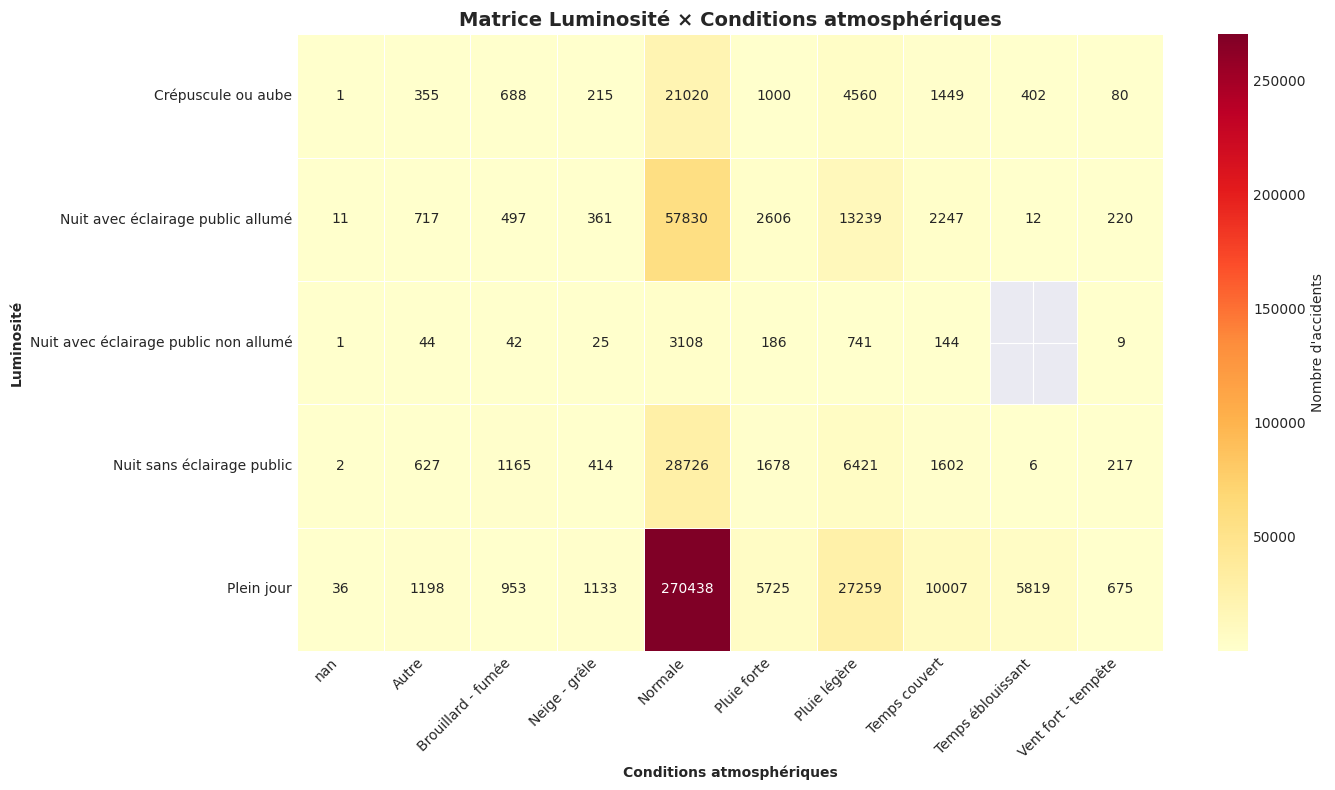

In [29]:
pivot_2_2 = df_4_4.pivot(index='luminosite', columns='atmosphere', values='nb_accidents')
pivot_2_2.head()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot_2_2,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Nombre d\'accidents'},
    ax=ax
)
ax.set_title('Matrice Luminosité × Conditions atmosphériques', fontweight='bold', fontsize=14)
ax.set_xlabel('Conditions atmosphériques', fontweight='bold')
ax.set_ylabel('Luminosité', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [30]:
section='2'
chapitre='1'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.atm AS code_meteo,
        COUNT(*) AS nb_accidents,
        SUM(aua.nb_usagers_total) AS nb_personnes_impliquees,
        SUM(aua.nb_tues) AS nb_tues,
        SUM(aua.nb_blesses) AS nb_blesses
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.atm
)
SELECT
    code_meteo,
    nb_accidents,
    nb_personnes_impliquees,
    nb_tues,
    nb_blesses,
    ROUND(100.0 * nb_accidents / NULLIF(SUM(nb_accidents) OVER (), 0), 2) AS pct_accidents,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct,
    DENSE_RANK() OVER (ORDER BY nb_accidents DESC) AS rang
FROM stats
ORDER BY nb_accidents DESC;


,code_meteo,nb_accidents,nb_personnes_impliquees,nb_tues,nb_blesses,pct_accidents,taux_mortalite_pct,rang
0,Normale,381122,850913,22081,476664,80.08,2.59,1
1,Pluie légère,52220,114365,2680,65835,10.97,2.34,2
2,Temps couvert,15449,34423,1309,19461,3.25,3.80,3
3,Pluie forte,11195,25194,762,14522,2.35,3.02,4
4,Temps éblouissant,6239,14364,628,7558,1.31,4.37,5


In [31]:
section='2'
chapitre='2'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.surf AS code_surface,
        COUNT(*) AS nb_accidents,
        SUM(aua.nb_usagers_total) AS nb_personnes_impliquees,
        SUM(aua.nb_tues) AS nb_tues,
        SUM(aua.nb_blesses) AS nb_blesses
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.surf
)
SELECT
    code_surface,
    nb_accidents,
    nb_personnes_impliquees,
    nb_tues,
    nb_blesses,
    ROUND(100.0 * nb_accidents / NULLIF(SUM(nb_accidents) OVER (), 0), 2) AS pct_accidents,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct,
    DENSE_RANK() OVER (ORDER BY nb_accidents DESC) AS rang
FROM stats
ORDER BY nb_accidents DESC;


,code_surface,nb_accidents,nb_personnes_impliquees,nb_tues,nb_blesses,pct_accidents,taux_mortalite_pct,rang
0,normale,366719,823687,21914,458674,77.06,2.66,1
1,mouillée,84930,187253,5327,108143,17.85,2.84,2
2,None,16152,34165,538,19608,3.39,1.57,3
3,autre,2395,4361,254,2860,0.50,5.82,4
4,verglacée,2247,4588,239,2957,0.47,5.21,5


In [32]:
section='2'
chapitre='3'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.lum AS code_lumiere,
        COUNT(*) AS nb_accidents,
        SUM(aua.nb_usagers_total) AS nb_personnes_impliquees,
        SUM(aua.nb_tues) AS nb_tues,
        SUM(aua.nb_blesses) AS nb_blesses
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.lum
)
SELECT
    code_lumiere,
    nb_accidents,
    nb_personnes_impliquees,
    nb_tues,
    nb_blesses,
    ROUND(100.0 * nb_accidents / NULLIF(SUM(nb_accidents) OVER (), 0), 2) AS pct_accidents,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct,
    DENSE_RANK() OVER (ORDER BY nb_accidents DESC) AS rang
FROM stats
ORDER BY nb_accidents DESC;


,code_lumiere,nb_accidents,nb_personnes_impliquees,nb_tues,nb_blesses,pct_accidents,taux_mortalite_pct,rang
0,Plein jour,323243,726029,16349,401070,67.92,2.25,1
1,Nuit avec éclairage public allumé,77740,167707,2891,97537,16.33,1.72,2
2,Nuit sans éclairage public,40858,92932,6910,55521,8.59,7.44,3
3,Crépuscule ou aube,29770,65177,2087,37151,6.26,3.20,4
4,Nuit avec éclairage public non allumé,4300,9409,333,5460,0.90,3.54,5


In [33]:
section='2'
chapitre='4'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.code_collision,
        COUNT(*) AS nb_accidents,
        SUM(aua.nb_usagers_total) AS nb_personnes_impliquees,
        SUM(aua.nb_tues) AS nb_tues,
        SUM(aua.nb_blesses) AS nb_blesses
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.code_collision
)
SELECT
    code_collision,
    nb_accidents,
    nb_personnes_impliquees,
    nb_tues,
    nb_blesses,
    ROUND(100.0 * nb_accidents / NULLIF(SUM(nb_accidents) OVER (), 0), 2) AS pct_accidents,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct,
    DENSE_RANK() OVER (ORDER BY nb_accidents DESC) AS rang
FROM stats
ORDER BY nb_accidents DESC;


,code_collision,nb_accidents,nb_personnes_impliquees,nb_tues,nb_blesses,pct_accidents,taux_mortalite_pct,rang
0,Autre collision,161298,299538,12083,180151,33.89,4.03,1
1,Deux véhicules – par le coté,132605,309461,3847,164853,27.86,1.24,2
2,Deux véhicules – par l’arrière,58352,139192,1451,73824,12.26,1.04,3
3,Sans collision,46028,65912,3269,51213,9.67,4.96,4
4,Deux véhicules - frontale,45192,115256,5783,69148,9.50,5.02,5


In [34]:
section='2'
chapitre='5'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH vehicules AS (
    SELECT
        v.num_acc,
        v.catv,
        COUNT(*) AS nb_vehicules_cat_acc
    FROM VEHICULE v
    GROUP BY v.num_acc, v.catv
),
stats AS (
    SELECT
        v.catv AS code_categorie_vehicule,
        SUM(v.nb_vehicules_cat_acc) AS nb_vehicules,
        COUNT(*) AS nb_accidents,
        SUM(aua.nb_usagers_total) AS nb_personnes_impliquees,
        SUM(aua.nb_tues) AS nb_tues
    FROM vehicules v
    INNER JOIN analytics.accident_usagers_aggr aua USING (num_acc)
    GROUP BY v.catv
)
SELECT
    code_categorie_vehicule,
    nb_vehicules,
    nb_accidents,
    nb_personnes_impliquees,
    nb_tues,
    ROUND(100.0 * nb_vehicules / NULLIF(SUM(nb_vehicules) OVER (), 0), 2) AS pct_vehicules,
    ROUND(100.0 * nb_accidents / NULLIF(SUM(nb_accidents) OVER (), 0), 2) AS pct_accidents
FROM stats
ORDER BY nb_vehicules DESC;


,code_categorie_vehicule,nb_vehicules,nb_accidents,nb_personnes_impliquees,nb_tues,pct_vehicules,pct_accidents
0,VL seul,502874,373228,884226,21301,61.98,55.51
1,Motocyclette > 125 cm3,67462,65843,133948,4504,8.31,9.79
2,VU seul 1,46223,42720,109557,2955,5.70,6.35
3,Bicyclette,37757,36580,71174,1429,4.65,5.44
4,Scooter < 50 cm3,30904,30440,59540,685,3.81,4.53


In [35]:
section='2'
chapitre='6'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH usagers AS (
    SELECT
        u.num_acc,
        u.catu,
        COUNT(*) AS nb_personnes,
        SUM(CASE WHEN u.grav = 'Indemne' THEN 1 ELSE 0 END) AS nb_indemnes,
        SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) AS nb_tues,
        SUM(CASE WHEN u.grav = 'Blessé' THEN 1 ELSE 0 END) AS nb_blesses
        FROM USAGER u
    GROUP BY u.num_acc, u.catu
),
stats AS (
    SELECT
        u.catu AS code_categorie_usager,
        SUM(u.nb_personnes) AS nb_personnes,
        SUM(u.nb_indemnes) AS nb_indemnes,
        SUM(u.nb_tues) AS nb_tues,
        SUM(u.nb_blesses) AS nb_blesses,
        COUNT(*) AS nb_accidents
    FROM usagers u
    GROUP BY u.catu
)
SELECT
    code_categorie_usager,
    nb_personnes,
    nb_accidents,
    nb_indemnes,
    nb_tues,
    nb_blesses,
    ROUND(100.0 * nb_personnes / NULLIF(SUM(nb_personnes) OVER (), 0), 2) AS pct_usagers,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes, 0), 2) AS taux_mortalite_pct,
    DENSE_RANK() OVER (ORDER BY nb_personne

,code_categorie_usager,nb_personnes,nb_accidents,nb_indemnes,nb_tues,nb_blesses,pct_usagers,taux_mortalite_pct,rang
0,Conducteur,788583,468135,376514,19814,392255,74.31,2.51,1
1,Passager,178561,110605,57576,4506,116479,16.83,2.52,2
2,Piéton,92477,87132,1816,4223,86438,8.71,4.57,3
3,Piéton en roller ou en trottinette,1633,1599,39,27,1567,0.15,1.65,4


In [36]:
section='2'
chapitre='7'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.atm AS code_meteo,
        COUNT(*) AS nb_accidents_total,
        SUM(aua.nb_tues) AS nb_tues,
        SUM(CASE WHEN aua.nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.atm
)
SELECT
    code_meteo,
    nb_accidents_mortels,
    nb_tues,
    nb_accidents_total,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(SUM(nb_accidents_mortels) OVER (), 0), 2) AS pct_accidents_mortels,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(nb_accidents_total, 0), 2) AS taux_accidents_mortels_pct
FROM stats
ORDER BY nb_tues DESC;


,code_meteo,nb_accidents_mortels,nb_tues,nb_accidents_total,pct_accidents_mortels,taux_accidents_mortels_pct
0,Normale,20589,22081,381122,77.50,5.40
1,Pluie légère,2470,2680,52220,9.30,4.73
2,Temps couvert,1198,1309,15449,4.51,7.75
3,Pluie forte,704,762,11195,2.65,6.29
4,Temps éblouissant,591,628,6239,2.22,9.47


In [37]:
section='2'
chapitre='8'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.surf AS code_surface,
        COUNT(*) AS nb_accidents_total,
        SUM(aua.nb_tues) AS nb_tues,
        SUM(CASE WHEN aua.nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.surf
)
SELECT
    code_surface,
    nb_accidents_mortels,
    nb_tues,
    nb_accidents_total,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(SUM(nb_accidents_mortels) OVER (), 0), 2) AS pct_accidents_mortels,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(nb_accidents_total, 0), 2) AS taux_accidents_mortels_pct
FROM stats
ORDER BY nb_tues DESC;


,code_surface,nb_accidents_mortels,nb_tues,nb_accidents_total,pct_accidents_mortels,taux_accidents_mortels_pct
0,normale,20449,21914,366719,76.97,5.58
1,mouillée,4870,5327,84930,18.33,5.73
2,None,517,538,16152,1.95,3.20
3,autre,239,254,2395,0.90,9.98
4,verglacée,220,239,2247,0.83,9.79


In [38]:
section='2'
chapitre='9'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.lum AS code_lumiere,
        COUNT(*) AS nb_accidents_total,
        SUM(aua.nb_tues) AS nb_tues,
        SUM(CASE WHEN aua.nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.lum
)
SELECT
    code_lumiere,
    nb_accidents_mortels,
    nb_tues,
    nb_accidents_total,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(SUM(nb_accidents_mortels) OVER (), 0), 2) AS pct_accidents_mortels,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(nb_accidents_total, 0), 2) AS taux_accidents_mortels_pct
FROM stats
ORDER BY nb_tues DESC;


,code_lumiere,nb_accidents_mortels,nb_tues,nb_accidents_total,pct_accidents_mortels,taux_accidents_mortels_pct
0,Plein jour,15334,16349,323243,57.72,4.74
1,Nuit sans éclairage public,6274,6910,40858,23.61,15.36
2,Nuit avec éclairage public allumé,2723,2891,77740,10.25,3.50
3,Crépuscule ou aube,1931,2087,29770,7.27,6.49
4,Nuit avec éclairage public non allumé,306,333,4300,1.15,7.12


In [39]:
section='2'
chapitre='10'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.code_collision,
        COUNT(*) AS nb_accidents_total,
        SUM(aua.nb_tues) AS nb_tues,
        SUM(CASE WHEN aua.nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.code_collision
)
SELECT
    code_collision,
    nb_accidents_mortels,
    nb_tues,
    nb_accidents_total,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(SUM(nb_accidents_mortels) OVER (), 0), 2) AS pct_accidents_mortels,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(nb_accidents_total, 0), 2) AS taux_accidents_mortels_pct
FROM stats
ORDER BY nb_tues DESC;


,code_collision,nb_accidents_mortels,nb_tues,nb_accidents_total,pct_accidents_mortels,taux_accidents_mortels_pct
0,Autre collision,11526,12083,161298,43.38,7.15
1,Deux véhicules - frontale,5117,5783,45192,19.26,11.32
2,Deux véhicules – par le coté,3586,3847,132605,13.50,2.70
3,Sans collision,3138,3269,46028,11.81,6.82
4,Trois véhicules et plus - collisions multiples,1460,1715,15508,5.50,9.41


In [40]:
section='2'
chapitre='11'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH vehicules AS (
    SELECT
        v.num_acc,
        v.catv,
        COUNT(*) AS nb_vehicules_cat_acc
    FROM VEHICULE v
    GROUP BY v.num_acc, v.catv
),
stats AS (
    SELECT
        v.catv AS code_categorie_vehicule,
        SUM(v.nb_vehicules_cat_acc) AS nb_vehicules,
        COUNT(*) AS nb_accidents,
        SUM(CASE WHEN aua.nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels,
        SUM(aua.nb_tues) AS nb_tues
    FROM vehicules v
    INNER JOIN analytics.accident_usagers_aggr aua USING (num_acc)
    GROUP BY v.catv
)
SELECT
    code_categorie_vehicule,
    nb_accidents_mortels,
    nb_tues,
    nb_accidents,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(SUM(nb_accidents_mortels) OVER (), 0), 2) AS pct_accidents_mortels
FROM stats
ORDER BY nb_tues DESC;


,code_categorie_vehicule,nb_accidents_mortels,nb_tues,nb_accidents,pct_accidents_mortels
0,VL seul,19544,21301,373228,54.98
1,Motocyclette > 125 cm3,4347,4504,65843,12.23
2,VU seul 1,2717,2955,42720,7.64
3,Bicyclette,1421,1429,36580,4.00
4,Tracteur routier + semi-remorque,1043,1216,5347,2.93


In [41]:
section='2'
chapitre='12'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH usagers AS (
    SELECT
        u.num_acc,
        u.catu,
        COUNT(*) AS nb_personnes,
        SUM(CASE WHEN u.grav = 'Tué' THEN 1 ELSE 0 END) AS nb_tues
    FROM USAGER u
    GROUP BY u.num_acc, u.catu
),
stats AS (
    SELECT
        u.catu AS code_categorie_usager,
        SUM(u.nb_personnes) AS nb_personnes_total,
        SUM(u.nb_tues) AS nb_tues,
        SUM(CASE WHEN u.nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels
    FROM usagers u
    GROUP BY u.catu
)
SELECT
    code_categorie_usager,
    nb_tues,
    nb_personnes_total,
    nb_accidents_mortels,
    ROUND(100.0 * nb_tues / NULLIF(SUM(nb_tues) OVER (), 0), 2) AS pct_tues,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_total, 0), 2) AS taux_mortalite_pct
FROM stats
ORDER BY nb_tues DESC;


,code_categorie_usager,nb_tues,nb_personnes_total,nb_accidents_mortels,pct_tues,taux_mortalite_pct
0,Conducteur,19814,788583,19539,69.35,2.51
1,Passager,4506,178561,4015,15.77,2.52
2,Piéton,4223,92477,4170,14.78,4.57
3,Piéton en roller ou en trottinette,27,1633,27,0.09,1.65


---

## 4. Section 3 : Tendances temporelles

### 3.1 - Évolution annuelle

In [42]:
section='3'
chapitre='1'
df_3_1 =execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_3_1.head()

WITH stats AS (
    SELECT
        an AS annee,
        COUNT(*) AS nb_accidents,
        SUM(nb_usagers_total) AS nb_personnes_impliquees,
        SUM(nb_indemnes) AS nb_indemnes,
        SUM(nb_tues) AS nb_tues,
        SUM(nb_blesses) AS nb_blesses,
        SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels
    FROM analytics.accident_usagers_aggr
    WHERE an IS NOT NULL
    GROUP BY an
)
SELECT
    annee,
    nb_accidents,
    nb_personnes_impliquees,
    nb_indemnes,
    nb_tues,
    nb_blesses,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(nb_accidents, 0), 2) AS pct_accidents_mortels,
    LAG(nb_accidents) OVER (ORDER BY annee) AS nb_accidents_annee_prec,
    nb_accidents - LAG(nb_accidents) OVER (ORDER BY annee) AS evolution_accidents,
    ROUND(100.0 * (nb_accidents - LAG(nb_accidents) OVER (ORDER BY annee)) /
          NULLIF(LAG(nb_accidents) OVER (ORDER BY annee), 

,annee,nb_accidents,nb_personnes_impliquees,nb_indemnes,nb_tues,nb_blesses,taux_mortalite_pct,pct_accidents_mortels,nb_accidents_annee_prec,evolution_accidents,pct_evolution
0,2012,62250,138469,56491,3842,78136,2.77,5.72,NaN,NaN,None
1,2013,58397,128572,52599,3426,72547,2.66,5.43,62250.00,-3853.00,-6.19
2,2014,59854,132044,53416,3554,75074,2.69,5.52,58397.00,1457.00,2.49
3,2015,58654,130273,53353,3608,73312,2.77,5.64,59854.00,-1200.00,-2.00
4,2016,59432,133200,54514,3652,75034,2.74,5.71,58654.00,778.00,1.33


#### Visualisation : 

In [43]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_bar(
    x=df_3_1['annee'],
    y=df_3_1['nb_accidents'],
    name='Accidents',
    marker_color=PALETTE['primary'],
    hovertemplate='%{x}: %{y:,} accidents<extra></extra>',
)

fig.add_scatter(
    x=df_3_1['annee'],
    y=df_3_1['pct_evolution'],
    mode='lines+markers',
    name='Évolution %',
    line=dict(color=PALETTE['secondary'], width=3),
    marker=dict(size=8),
    hovertemplate='%{x}: %{y:.1f}%<extra></extra>',
    secondary_y=True,
)

fig.add_scatter(
    x=df_3_1['annee'],
    y=df_3_1['nb_accidents'].rolling(3, center=True).mean(),
    mode='lines',
    name='Tendance',
    line=dict(color=PALETTE['neutral'], width=2, dash='dash'),
)

fig.update_layout(
    title='Accidents et variation annuelle (2012‑2019)',
    xaxis_title='Année',
    yaxis=dict(title='Nombre d’accidents'),
    yaxis2=dict(title='Variation (%)', tickformat='.00%', rangemode='tozero'),
    hovermode='x unified',
    height=500,
)

fig.update_yaxes(
   
    showticklabels=False,
    ticks="",
    secondary_y=True
)
fig.show()

In [44]:
section='3'
chapitre='2'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        mois,
        COUNT(*) AS nb_accidents,
        COUNT(DISTINCT an) AS nb_annees_observees,
        SUM(nb_usagers_total) AS nb_personnes_impliquees,
        SUM(nb_tues) AS nb_tues
    FROM analytics.accident_usagers_aggr
    WHERE mois IS NOT NULL
    GROUP BY mois
)
SELECT
    mois,
    CASE mois
        WHEN 1 THEN 'Janvier'
        WHEN 2 THEN 'Février'
        WHEN 3 THEN 'Mars'
        WHEN 4 THEN 'Avril'
        WHEN 5 THEN 'Mai'
        WHEN 6 THEN 'Juin'
        WHEN 7 THEN 'Juillet'
        WHEN 8 THEN 'Août'
        WHEN 9 THEN 'Septembre'
        WHEN 10 THEN 'Octobre'
        WHEN 11 THEN 'Novembre'
        WHEN 12 THEN 'Décembre'
    END AS nom_mois,
    nb_accidents,
    nb_personnes_impliquees,
    nb_tues,
    ROUND(nb_accidents::NUMERIC / NULLIF(nb_annees_observees, 0), 2) AS moyenne_accidents_par_an,
    ROUND(100.0 * nb_accidents / NULLIF(SUM(nb_accidents) OVER (), 0), 2) AS pct_accidents,
    ROUND(100.0 * nb_tues / NULLIF(nb_pers

,mois,nom_mois,nb_accidents,nb_personnes_impliquees,nb_tues,moyenne_accidents_par_an,pct_accidents,taux_mortalite_pct
0,1,Janvier,36639,80696,2112,4579.88,7.70,2.62
1,2,Février,31931,70463,1925,3991.38,6.71,2.73
2,3,Mars,37040,82116,2095,4630.00,7.78,2.55
3,4,Avril,37912,84528,2174,4739.00,7.97,2.57
4,5,Mai,40331,89807,2297,5041.38,8.47,2.56


In [45]:
section='3'
chapitre='3'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        CASE WHEN hrmn IS NOT NULL THEN EXTRACT(HOUR FROM hrmn)::INT ELSE NULL END AS heure_num,
        COUNT(*) AS nb_accidents,
        SUM(nb_usagers_total) AS nb_personnes_impliquees,
        SUM(nb_tues) AS nb_tues
    FROM analytics.accident_usagers_aggr
    GROUP BY 1
)
SELECT
    CASE
        WHEN heure_num IS NULL THEN 'NR'
        ELSE LPAD(heure_num::TEXT, 2, '0')
    END AS heure,
    nb_accidents,
    nb_personnes_impliquees,
    nb_tues,
    ROUND(100.0 * nb_accidents / NULLIF(SUM(nb_accidents) OVER (), 0), 2) AS pct_accidents,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct,
    CASE
        WHEN heure_num IS NULL THEN 'Non renseigné'
        WHEN heure_num BETWEEN 0 AND 5 THEN 'Nuit (00h-06h)'
        WHEN heure_num BETWEEN 6 AND 8 THEN 'Matin (06h-09h)'
        WHEN heure_num BETWEEN 9 AND 11 THEN 'Matinée (09h-12h)'
        WHEN heure_num BETWEEN 12 AND 13 THEN 'Midi (12h-14h)'
        WHEN heure_num

,heure,nb_accidents,nb_personnes_impliquees,nb_tues,pct_accidents,taux_mortalite_pct,tranche_horaire
0,00,8348,18418,776,1.75,4.21,Nuit (00h-06h)
1,01,6831,14582,736,1.44,5.05,Nuit (00h-06h)
2,02,5803,11969,654,1.22,5.46,Nuit (00h-06h)
3,03,4732,9540,621,0.99,6.51,Nuit (00h-06h)
4,04,4949,10167,664,1.04,6.53,Nuit (00h-06h)


In [46]:
section='3'
chapitre='4'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        EXTRACT(ISODOW FROM make_date(an::int, mois::int, jour::int))::INT AS numero_jour,
        COUNT(*) AS nb_accidents,
        SUM(nb_usagers_total) AS nb_personnes_impliquees,
        SUM(nb_tues) AS nb_tues,
        COUNT(DISTINCT make_date(an::int, mois::int, jour::int)) AS nb_jours_observes
    FROM analytics.accident_usagers_aggr
    WHERE an IS NOT NULL AND mois IS NOT NULL AND jour IS NOT NULL
    GROUP BY 1
)
SELECT
    numero_jour,
    CASE numero_jour
        WHEN 1 THEN 'Lundi'
        WHEN 2 THEN 'Mardi'
        WHEN 3 THEN 'Mercredi'
        WHEN 4 THEN 'Jeudi'
        WHEN 5 THEN 'Vendredi'
        WHEN 6 THEN 'Samedi'
        WHEN 7 THEN 'Dimanche'
        ELSE 'Non renseigné'
    END AS nom_jour,
    CASE
        WHEN numero_jour IN (6, 7) THEN 'Weekend'
        WHEN numero_jour BETWEEN 1 AND 5 THEN 'Semaine'
        ELSE 'Indéterminé'
    END AS type_jour,
    nb_accidents,
    nb_personnes_impliquees,
    nb_tues,
    ROUND(nb_accident

,numero_jour,nom_jour,type_jour,nb_accidents,nb_personnes_impliquees,nb_tues,moyenne_accidents_par_occurrence,pct_accidents,taux_mortalite_pct
0,1,Lundi,Semaine,64650,141984,3545,154.67,13.58,2.50
1,2,Mardi,Semaine,69643,152034,3495,166.61,14.63,2.30
2,3,Mercredi,Semaine,69434,152649,3548,166.51,14.59,2.32
3,4,Jeudi,Semaine,71031,154635,3783,170.34,14.93,2.45
4,5,Vendredi,Semaine,79539,176785,4668,190.74,16.71,2.64


In [138]:
section='3'
chapitre='5'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        an AS annee,
        COUNT(*) AS nb_accidents_total,
        SUM(nb_tues) AS nb_tues,
        SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels
    FROM analytics.accident_usagers_aggr
    WHERE an IS NOT NULL
    GROUP BY an
)
SELECT
    annee,
    nb_accidents_mortels,
    nb_tues,
    nb_accidents_total,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(nb_accidents_total, 0), 2) AS pct_accidents_mortels,
    LAG(nb_tues) OVER (ORDER BY annee) AS nb_tues_annee_prec,
    nb_tues - LAG(nb_tues) OVER (ORDER BY annee) AS evolution_tues,
    ROUND(100.0 * (nb_tues - LAG(nb_tues) OVER (ORDER BY annee)) /
          NULLIF(LAG(nb_tues) OVER (ORDER BY annee), 0), 2) AS pct_evolution_tues
FROM stats
ORDER BY annee;


,annee,nb_accidents_mortels,nb_tues,nb_accidents_total,pct_accidents_mortels,nb_tues_annee_prec,evolution_tues,pct_evolution_tues
0,2012,3563,3842,62250,5.72,None,None,None
1,2013,3171,3426,58397,5.43,3842,-416,-10.83
2,2014,3305,3554,59854,5.52,3426,128,3.74
3,2015,3306,3608,58654,5.64,3554,54,1.52
4,2016,3393,3652,59432,5.71,3608,44,1.22


In [47]:
section='3'
chapitre='6'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        mois,
        COUNT(*) AS nb_accidents_total,
        SUM(nb_tues) AS nb_tues,
        SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels
    FROM analytics.accident_usagers_aggr
    WHERE mois IS NOT NULL
    GROUP BY mois
)
SELECT
    mois,
    CASE mois
        WHEN 1 THEN 'Janvier'
        WHEN 2 THEN 'Février'
        WHEN 3 THEN 'Mars'
        WHEN 4 THEN 'Avril'
        WHEN 5 THEN 'Mai'
        WHEN 6 THEN 'Juin'
        WHEN 7 THEN 'Juillet'
        WHEN 8 THEN 'Août'
        WHEN 9 THEN 'Septembre'
        WHEN 10 THEN 'Octobre'
        WHEN 11 THEN 'Novembre'
        WHEN 12 THEN 'Décembre'
    END AS nom_mois,
    nb_accidents_mortels,
    nb_tues,
    nb_accidents_total,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(SUM(nb_accidents_mortels) OVER (), 0), 2) AS pct_accidents_mortels,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(nb_accidents_total, 0), 2) AS taux_accidents_mortels_pct
FROM stats
ORDER BY mois;


,mois,nom_mois,nb_accidents_mortels,nb_tues,nb_accidents_total,pct_accidents_mortels,taux_accidents_mortels_pct
0,1,Janvier,1985,2112,36639,7.47,5.42
1,2,Février,1796,1925,31931,6.76,5.62
2,3,Mars,1937,2095,37040,7.29,5.23
3,4,Avril,2021,2174,37912,7.61,5.33
4,5,Mai,2120,2297,40331,7.98,5.26


In [48]:
section='3'
chapitre='7'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        CASE WHEN hrmn IS NOT NULL THEN EXTRACT(HOUR FROM hrmn)::INT ELSE NULL END AS heure_num,
        COUNT(*) AS nb_accidents_total,
        SUM(nb_tues) AS nb_tues,
        SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels
    FROM analytics.accident_usagers_aggr
    GROUP BY 1
)
SELECT
    CASE
        WHEN heure_num IS NULL THEN 'NR'
        ELSE LPAD(heure_num::TEXT, 2, '0')
    END AS heure,
    nb_accidents_mortels,
    nb_tues,
    nb_accidents_total,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(SUM(nb_accidents_mortels) OVER (), 0), 2) AS pct_accidents_mortels,
    CASE
        WHEN heure_num IS NULL THEN 'Non renseigné'
        WHEN heure_num BETWEEN 0 AND 5 THEN 'Nuit (00h-06h)'
        WHEN heure_num BETWEEN 6 AND 8 THEN 'Matin (06h-09h)'
        WHEN heure_num BETWEEN 9 AND 11 THEN 'Matinée (09h-12h)'
        WHEN heure_num BETWEEN 12 AND 13 THEN 'Midi (12h-14h)'
        WHEN heure_num BETWEEN 14 AND 17 THEN 'Après-midi (

,heure,nb_accidents_mortels,nb_tues,nb_accidents_total,pct_accidents_mortels,tranche_horaire
0,00,710,776,8348,2.67,Nuit (00h-06h)
1,01,669,736,6831,2.52,Nuit (00h-06h)
2,02,609,654,5803,2.29,Nuit (00h-06h)
3,03,552,621,4732,2.08,Nuit (00h-06h)
4,04,610,664,4949,2.30,Nuit (00h-06h)


In [49]:
section='3'
chapitre='8'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        EXTRACT(ISODOW FROM make_date(an::int, mois::int, jour::int))::INT AS numero_jour,
        COUNT(*) AS nb_accidents_total,
        SUM(nb_tues) AS nb_tues,
        SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels
    FROM analytics.accident_usagers_aggr
    WHERE an IS NOT NULL AND mois IS NOT NULL AND jour IS NOT NULL
    GROUP BY 1
)
SELECT
    numero_jour,
    CASE numero_jour
        WHEN 1 THEN 'Lundi'
        WHEN 2 THEN 'Mardi'
        WHEN 3 THEN 'Mercredi'
        WHEN 4 THEN 'Jeudi'
        WHEN 5 THEN 'Vendredi'
        WHEN 6 THEN 'Samedi'
        WHEN 7 THEN 'Dimanche'
        ELSE 'Non renseigné'
    END AS nom_jour,
    CASE
        WHEN numero_jour IN (6, 7) THEN 'Weekend'
        WHEN numero_jour BETWEEN 1 AND 5 THEN 'Semaine'
        ELSE 'Indéterminé'
    END AS type_jour,
    nb_accidents_mortels,
    nb_tues,
    nb_accidents_total,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(SUM(nb_accidents_mortels) OVER 

,numero_jour,nom_jour,type_jour,nb_accidents_mortels,nb_tues,nb_accidents_total,pct_accidents_mortels,taux_accidents_mortels_pct
0,1,Lundi,Semaine,3352,3545,64650,12.62,5.18
1,2,Mardi,Semaine,3295,3495,69643,12.40,4.73
2,3,Mercredi,Semaine,3347,3548,69434,12.60,4.82
3,4,Jeudi,Semaine,3554,3783,71031,13.38,5.00
4,5,Vendredi,Semaine,4316,4668,79539,16.25,5.43


### 3.2 - Heatmap jour × heure

In [50]:
# Section 3.2 : Heatmap jour × heure (requête custom)
# Note : Requête custom (croisement jour × heure)

if USE_MOCK_DATA:
    df_3_2 = MOCK_DATA['3_2']
    print("📊 Données mockées chargées")
else:
    # Requête custom (heatmap jour × heure)
    query_3_2 = """
SELECT
    jour,
    EXTRACT(HOUR FROM hrmn::time) as heure,
    COUNT(*) as nb_accidents
FROM analytics.accident_usagers_aggr
WHERE jour IS NOT NULL AND hrmn IS NOT NULL
GROUP BY jour, EXTRACT(HOUR FROM hrmn::time)
"""
    df_3_2 = pd.read_sql(query_3_2, engine)
    print(f"✅ Requête exécutée - {len(df_3_2):,} lignes")

# Noms des jours
jours_noms = {1: 'Lundi', 2: 'Mardi', 3: 'Mercredi', 4: 'Jeudi',
              5: 'Vendredi', 6: 'Samedi', 7: 'Dimanche'}
df_3_2['jour_nom'] = df_3_2['jour'].map(jours_noms)

# Pivot
pivot_3_2 = df_3_2.pivot(index='jour_nom', columns='heure', values='nb_accidents')

# Réordonner les jours
ordre_jours = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
pivot_3_2 = pivot_3_2.reindex(ordre_jours)

pivot_3_2.head()

NameError: name 'engine' is not defined

In [51]:
section='3'
chapitre='3'
df_3_3 =execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_3_3.head()

WITH stats AS (
    SELECT
        CASE WHEN hrmn IS NOT NULL THEN EXTRACT(HOUR FROM hrmn)::INT ELSE NULL END AS heure_num,
        COUNT(*) AS nb_accidents,
        SUM(nb_usagers_total) AS nb_personnes_impliquees,
        SUM(nb_tues) AS nb_tues
    FROM analytics.accident_usagers_aggr
    GROUP BY 1
)
SELECT
    CASE
        WHEN heure_num IS NULL THEN 'NR'
        ELSE LPAD(heure_num::TEXT, 2, '0')
    END AS heure,
    nb_accidents,
    nb_personnes_impliquees,
    nb_tues,
    ROUND(100.0 * nb_accidents / NULLIF(SUM(nb_accidents) OVER (), 0), 2) AS pct_accidents,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct,
    CASE
        WHEN heure_num IS NULL THEN 'Non renseigné'
        WHEN heure_num BETWEEN 0 AND 5 THEN 'Nuit (00h-06h)'
        WHEN heure_num BETWEEN 6 AND 8 THEN 'Matin (06h-09h)'
        WHEN heure_num BETWEEN 9 AND 11 THEN 'Matinée (09h-12h)'
        WHEN heure_num BETWEEN 12 AND 13 THEN 'Midi (12h-14h)'
        WHEN heure_num

,heure,nb_accidents,nb_personnes_impliquees,nb_tues,pct_accidents,taux_mortalite_pct,tranche_horaire
0,00,8348,18418,776,1.75,4.21,Nuit (00h-06h)
1,01,6831,14582,736,1.44,5.05,Nuit (00h-06h)
2,02,5803,11969,654,1.22,5.46,Nuit (00h-06h)
3,03,4732,9540,621,0.99,6.51,Nuit (00h-06h)
4,04,4949,10167,664,1.04,6.53,Nuit (00h-06h)


In [52]:
fig = go.Figure()

fig.add_bar(
    x=df_3_3["heure"],
    y=df_3_3["nb_accidents"],
    name="Accidents",
    marker_color="#004c6d",
    opacity=0.85
)

fig.add_trace(go.Scatter(
    x=df_3_3["heure"],
    y=df_3_3["nb_personnes_impliquees"],
    name="Personnes impliquées",
    mode="lines+markers",
    line=dict(color="#00a6d6", width=2, dash="dot"),
    marker=dict(size=6)
))

fig.add_trace(go.Scatter(
    x=df_3_3["heure"],
    y=df_3_3["nb_tues"],
    name="Tués",
    mode="lines+markers",
    line=dict(color="#d64545", width=2),
    marker=dict(size=6, symbol="triangle-up")
))

fig.add_trace(go.Scatter(
    x=df_3_3["heure"],
    y=df_3_3["pct_accidents"] / 100,
    name="Pourcentage des accidents",
    mode="lines+markers",
    line=dict(color="#f2a900", width=3),
    marker=dict(size=7),
    yaxis="y2"
))

fig.update_layout(
    title="Accidents par heure",
    xaxis=dict(title="Heure", tickmode="linear"),
    yaxis=dict(title="Volume (accidents / personnes)"),
    yaxis2=dict(title="Part des accidents (%)", overlaying="y", side="right", tickformat=".0%"),
    legend=dict(orientation="h", y=1.1),
    template="plotly_white",
    bargap=0.2
)

fig.update_traces(hovertemplate="%{y}<extra>%{fullData.name}</extra>")
fig.show()

In [53]:
section='3'
chapitre='4'
df_3_4 =execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_3_4.head()

WITH stats AS (
    SELECT
        EXTRACT(ISODOW FROM make_date(an::int, mois::int, jour::int))::INT AS numero_jour,
        COUNT(*) AS nb_accidents,
        SUM(nb_usagers_total) AS nb_personnes_impliquees,
        SUM(nb_tues) AS nb_tues,
        COUNT(DISTINCT make_date(an::int, mois::int, jour::int)) AS nb_jours_observes
    FROM analytics.accident_usagers_aggr
    WHERE an IS NOT NULL AND mois IS NOT NULL AND jour IS NOT NULL
    GROUP BY 1
)
SELECT
    numero_jour,
    CASE numero_jour
        WHEN 1 THEN 'Lundi'
        WHEN 2 THEN 'Mardi'
        WHEN 3 THEN 'Mercredi'
        WHEN 4 THEN 'Jeudi'
        WHEN 5 THEN 'Vendredi'
        WHEN 6 THEN 'Samedi'
        WHEN 7 THEN 'Dimanche'
        ELSE 'Non renseigné'
    END AS nom_jour,
    CASE
        WHEN numero_jour IN (6, 7) THEN 'Weekend'
        WHEN numero_jour BETWEEN 1 AND 5 THEN 'Semaine'
        ELSE 'Indéterminé'
    END AS type_jour,
    nb_accidents,
    nb_personnes_impliquees,
    nb_tues,
    ROUND(nb_accident

,numero_jour,nom_jour,type_jour,nb_accidents,nb_personnes_impliquees,nb_tues,moyenne_accidents_par_occurrence,pct_accidents,taux_mortalite_pct
0,1,Lundi,Semaine,64650,141984,3545,154.67,13.58,2.50
1,2,Mardi,Semaine,69643,152034,3495,166.61,14.63,2.30
2,3,Mercredi,Semaine,69434,152649,3548,166.51,14.59,2.32
3,4,Jeudi,Semaine,71031,154635,3783,170.34,14.93,2.45
4,5,Vendredi,Semaine,79539,176785,4668,190.74,16.71,2.64


#### Visualisation : Heatmap calendaire

In [ ]:
section='3'
chapitre='9'
df_3_9 =execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_3_9.head()

WITH base AS (
    SELECT
        EXTRACT(ISODOW FROM make_date(an::int, mois::int, jour::int))::INT AS numero_jour,
        EXTRACT(HOUR FROM hrmn)::INT AS heure_num,
        COUNT(*) AS nb_accidents
    FROM analytics.accident_usagers_aggr
    WHERE an IS NOT NULL
      AND mois IS NOT NULL
      AND jour IS NOT NULL
      AND hrmn IS NOT NULL
    GROUP BY 1, 2
),
jours AS (
    SELECT gs::INT AS numero_jour,
           CASE gs
               WHEN 1 THEN 'Lundi'
               WHEN 2 THEN 'Mardi'
               WHEN 3 THEN 'Mercredi'
               WHEN 4 THEN 'Jeudi'
               WHEN 5 THEN 'Vendredi'
               WHEN 6 THEN 'Samedi'
               WHEN 7 THEN 'Dimanche'
           END AS nom_jour,
           CASE
               WHEN gs BETWEEN 1 AND 5 THEN 'Semaine'
               ELSE 'Weekend'
           END AS type_jour
    FROM generate_series(1, 7) AS gs
),
heures AS (
    SELECT gs AS heure_num,
           LPAD(gs::TEXT, 2, '0') AS heure
    FROM generate_series(0, 23) 

,numero_jour,nom_jour,type_jour,heure_num,heure,nb_accidents
0,1,Lundi,Semaine,0,00,869
1,1,Lundi,Semaine,1,01,548
2,1,Lundi,Semaine,2,02,399
3,1,Lundi,Semaine,3,03,316
4,1,Lundi,Semaine,4,04,380


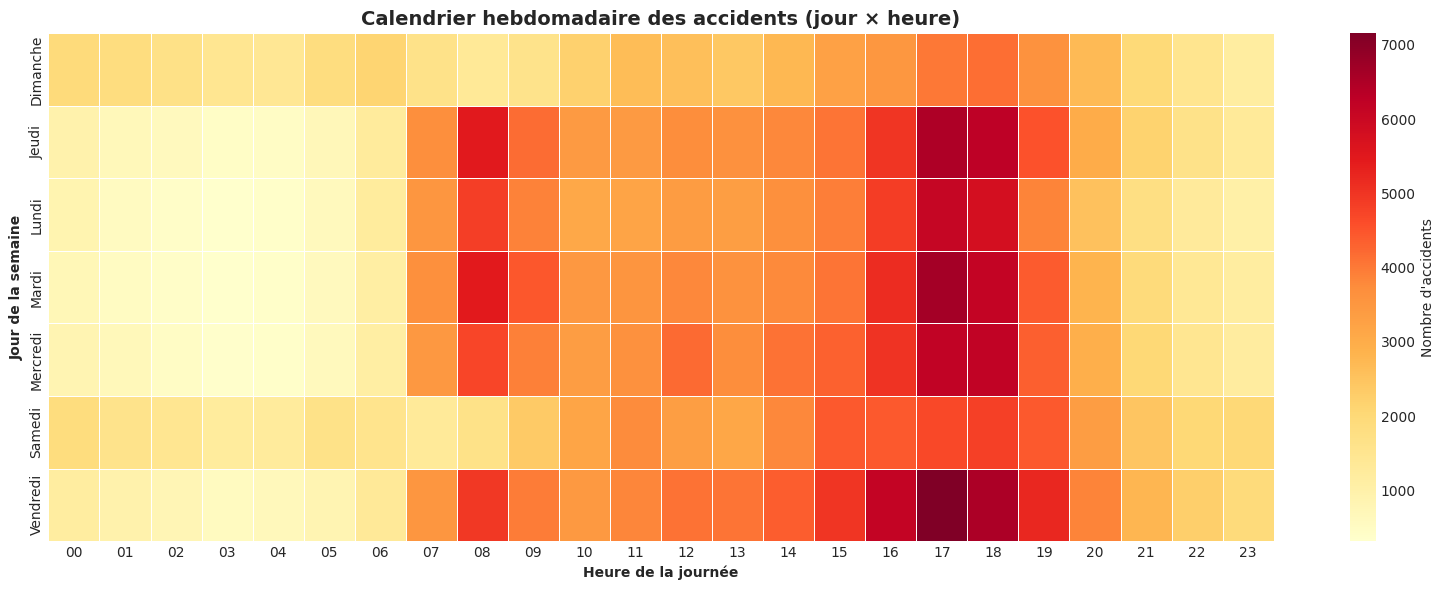

In [57]:
df = df_3_9
pivot_3_9 = df.pivot(index='nom_jour', columns='heure', values='nb_accidents')

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot_3_9,
    cmap='YlOrRd',
    annot=False,
    cbar_kws={'label': 'Nombre d\'accidents'},
    linewidths=0.5,
    ax=ax
)
ax.set_title('Calendrier hebdomadaire des accidents (jour × heure)', fontweight='bold', fontsize=14)
ax.set_xlabel('Heure de la journée', fontweight='bold')
ax.set_ylabel('Jour de la semaine', fontweight='bold')
plt.tight_layout()
plt.show()

In [91]:
metrics_counts = [
    ("nb_accidents", "Accidents"),
    ("nb_personnes_impliquees", "Personnes impliquées"),
    ("nb_tues", "Décès"),
    #("moyenne_accidents_par_occurrence", "Accidents / occurrence"),
]
metrics_rates = [
    ("pct_accidents", "% des accidents"),
    ("taux_mortalite_pct", "% mortalité"),
]

fig = make_subplots(specs=[[{"secondary_y": True}]])

for col, label in metrics_counts:
    fig.add_trace(
        go.Bar(x=df_3_4['nom_jour'], y=df_3_4[col], name=label, opacity=0.8),
        secondary_y=False,
    )

for col, label in metrics_rates:
    fig.add_trace(
        go.Scatter(
            x=df_3_4['nom_jour'],
            y=df_3_4[col],
            mode="markers+lines",
            name=label,
            marker=dict(size=8),
        ),
        secondary_y=True,
    )

fig.update_layout(
    title="Profil des accidents par jour",
    barmode="group",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template="plotly_white",
)
fig.update_yaxes(title_text="Volumes", secondary_y=False)
fig.update_yaxes(title_text="Pourcentages (%)", secondary_y=True)

fig.show()

---

## 5. Section 4 : Conditions à risque

### 4.1 - Quadrant de risque (Fréquence × Gravité)

In [92]:
# Section 4.1 : Quadrant de risque
# Requête source : section4_kpi_*.sql
# Documentation : ../etl/sql/query_catalog.md#41

if USE_MOCK_DATA:
    df_4_1 = MOCK_DATA['4_1']
    print(f"📊 Données mockées chargées ({{len(df_4_1):,}} lignes)")
else:
    query_4_1 = loader.load_query('section4', '4.1')
    df_4_1 = pd.read_sql(query_4_1, engine)
    print(f"✅ Requête 4.1 exécutée - {{len(df_4_1):,}} lignes")

df_4_1.head()

NameError: name 'engine' is not defined

In [142]:
section='4'
chapitre='1'
execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])

WITH statistiques_nationales AS (
    SELECT
        COUNT(*) AS nb_accidents_total,
        SUM(nb_usagers_total) AS nb_victimes_total,
        SUM(nb_tues) AS total_tues,
        SUM(nb_blesses) AS total_blesses,
        SUM(100 * nb_tues + 7 * nb_blesses) AS somme_scores,
        SUM(10000 * nb_tues + 70 * nb_blesses) AS somme_scores_carres
    FROM analytics.accident_usagers_aggr
),
analyse_conditions AS (
    SELECT
        aua.atm,
        aua.lum,
        aua.catr,
        COUNT(*) AS nb_accidents,
        SUM(nb_usagers_total) AS nb_impliques,
        SUM(nb_tues) AS nb_tues,
        SUM(nb_blesses) AS nb_blesses,
        SUM(nb_blesses) AS nb_blesses_legers,
        SUM(100 * nb_tues + 7 * nb_blesses) AS somme_scores,
        SUM(10000 * nb_tues + 70 * nb_blesses) AS somme_scores_carres,
        SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels,
        SUM(CASE WHEN nb_tues > 0 OR nb_blesses > 0 THEN 1 ELSE 0 END) AS nb_accidents_graves
    FROM analytics.a

,atm,lum,catr,nb_accidents,nb_tues,nb_blesses,gravite_moyenne,gravite_max,gravite_moyenne_nationale,ecart_gravite,z_score,taux_mortalite,pct_accidents_mortels,pct_accidents_graves,niveau_risque
0,Vent fort - tempête,Nuit sans éclairage public,Route Départementale,146,34,167,16.99,100.00,6.6281710127829907,10.36,0.64,12.64,21.92,100.00,RISQUE MODÉRÉ
1,Temps couvert,Nuit sans éclairage public,Route Départementale,910,249,1207,16.65,100.00,6.6281710127829907,10.02,0.62,12.43,24.62,100.00,RISQUE MODÉRÉ
2,Brouillard - fumée,Nuit sans éclairage public,Route Départementale,826,178,1042,14.90,100.00,6.6281710127829907,8.27,0.51,10.57,19.85,100.00,RISQUE MODÉRÉ
3,Normale,Nuit sans éclairage public,Route Départementale,14554,3248,19180,14.83,100.00,6.6281710127829907,8.20,0.50,10.49,20.37,100.00,RISQUE MODÉRÉ
4,Autre,Nuit sans éclairage public,Route Départementale,418,85,557,14.47,100.00,6.6281710127829907,7.84,0.48,9.92,17.70,100.00,RISQUE MODÉRÉ
5,Brouillard - fumée,Nuit sans éclairage public,Voie Communale,103,20,129,14.23,100.00,6.6281710127829907,7.60,0.47,9.80,18.45,100.00,RISQUE MODÉRÉ
6,Temps couvert,Nuit sans éclairage public,Route Nationale,164,39,213,13.48,100.00,6.6281710127829907,6.85,0.42,9.75,20.73,100.00,RISQUE MODÉRÉ
7,Temps couvert,Nuit sans éclairage public,Voie Communale,177,32,214,13.09,100.00,6.6281710127829907,6.46,0.40,8.91,14.69,100.00,RISQUE MODÉRÉ
8,Pluie forte,Nuit sans éclairage public,Route Départementale,887,170,1271,12.98,100.00,6.6281710127829907,6.35,0.39,8.52,17.93,100.00,RISQUE MODÉRÉ
9,Pluie légère,Nuit sans éclairage public,Route Départementale,3259,604,4567,12.80,100.00,6.6281710127829907,6.17,0.38,8.37,16.88,100.00,RISQUE MODÉRÉ


In [143]:
section='4'
chapitre='2'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.atm AS code_meteo,
        COUNT(*) AS nb_accidents,
        SUM(nb_usagers_total) AS nb_personnes_impliquees,
        SUM(nb_tues) AS nb_tues,
        SUM(nb_blesses) AS nb_blesses_hospitalises,
        SUM(100 * nb_tues + 10 * nb_blesses) AS somme_scores
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.atm
)
SELECT
    code_meteo,
    nb_accidents,
    nb_tues,
    nb_blesses_hospitalises,
    ROUND(somme_scores::NUMERIC / NULLIF(nb_personnes_impliquees, 0), 2) AS gravite_moyenne,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite
FROM stats
ORDER BY gravite_moyenne DESC;


,code_meteo,nb_accidents,nb_tues,nb_blesses_hospitalises,gravite_moyenne,taux_mortalite
0,None,51,10,57,15.24,9.71
1,Vent fort - tempête,1201,151,1460,12.12,6.16
2,Brouillard - fumée,3345,462,4472,11.67,5.93
3,Autre,2941,292,3710,10.70,4.71
4,Temps éblouissant,6239,628,7558,9.63,4.37


In [144]:
section='4'
chapitre='3'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats AS (
    SELECT
        aua.lum AS code_lumiere,
        COUNT(*) AS nb_accidents,
        SUM(nb_usagers_total) AS nb_personnes_impliquees,
        SUM(nb_tues) AS nb_tues,
        SUM(nb_blesses) AS nb_blesses,
        SUM(100 * nb_tues + 10 * nb_blesses) AS somme_scores,
        SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.lum
)
SELECT
    code_lumiere,
    nb_accidents,
    nb_tues,
    nb_blesses,
    ROUND(somme_scores::NUMERIC / NULLIF(nb_personnes_impliquees, 0), 2) AS gravite_moyenne,
    ROUND(100.0 * nb_accidents_mortels / NULLIF(nb_accidents, 0), 2) AS pct_accidents_mortels
FROM stats
ORDER BY gravite_moyenne DESC;


,code_lumiere,nb_accidents,nb_tues,nb_blesses,gravite_moyenne,pct_accidents_mortels
0,Nuit sans éclairage public,40858,6910,55521,13.41,15.36
1,Nuit avec éclairage public non allumé,4300,333,5460,9.34,7.12
2,Crépuscule ou aube,29770,2087,37151,8.90,6.49
3,Plein jour,323243,16349,401070,7.78,4.74
4,Nuit avec éclairage public allumé,77740,2891,97537,7.54,3.50


#### Visualisation : Scatter plot avec quadrants

In [94]:
# Calculer les médianes pour les quadrants
mediane_freq = df_4_1['frequence'].median()
mediane_grav = df_4_1['gravite_moyenne'].median()

fig = px.scatter(
    df_4_1,
    x='frequence',
    y='gravite_moyenne',
    text='condition',
    size='frequence',
    color='gravite_moyenne',
    title='Quadrant de risque : Fréquence × Gravité moyenne',
    labels={
        'frequence': 'Fréquence (nombre d\'accidents)',
        'gravite_moyenne': 'Gravité moyenne (tués par accident)'
    },
    color_continuous_scale='RdYlGn_r',
    height=600
)

# Ajouter les lignes de quadrant
fig.add_hline(y=mediane_grav, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_vline(x=mediane_freq, line_dash="dash", line_color="gray", opacity=0.5)

fig.update_traces(textposition='top center')
fig.show()

NameError: name 'df_4_1' is not defined

---

## 6. Section 5 : Zones fréquentées

### 5.1 - Top 20 communes

In [95]:
# Section 5.1 : Top 20 communes
# Requête source : section5_kpi_*.sql
# Documentation : ../etl/sql/query_catalog.md#51

if USE_MOCK_DATA:
    df_5_1 = MOCK_DATA['5_1']
    print(f"📊 Données mockées chargées ({{len(df_5_1):,}} lignes)")
else:
    query_5_1 = loader.load_query('section5', '5.1')
    df_5_1 = pd.read_sql(query_5_1, engine)
    print(f"✅ Requête 5.1 exécutée - {{len(df_5_1):,}} lignes")

df_5_1.head()

NameError: name 'engine' is not defined

In [145]:
section='5'
chapitre='1'
execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])

WITH stats_departements AS (
    SELECT
        dep_code AS departement,
        dep_name AS nom_departement,
        COUNT(*) AS nb_accidents,
        SUM(nb_usagers_total) AS nb_personnes_impliquees,
        SUM(nb_tues) AS nb_tues,
        SUM(nb_blesses) AS nb_blesses,
        SUM(100 * nb_tues + 30 * nb_blesses)::NUMERIC AS somme_scores,
        SUM(CASE WHEN nb_tues > 0 OR nb_blesses > 0 THEN 1 ELSE 0 END) AS nb_accidents_graves,
        SUM(CASE WHEN nb_tues > 0 THEN 1 ELSE 0 END) AS nb_accidents_mortels
    FROM analytics.accident_usagers_aggr
    WHERE dep_code IS NOT NULL
    GROUP BY dep_code, dep_name
),
classements AS (
    SELECT
        sd.*,
        DENSE_RANK() OVER (ORDER BY sd.nb_accidents DESC) AS rang_volume,
        DENSE_RANK() OVER (ORDER BY (sd.somme_scores / NULLIF(sd.nb_personnes_impliquees, 0)) DESC) AS rang_gravite
    FROM stats_departements sd
)
SELECT
    departement,
    nom_departement,
    nb_accidents,
    rang_volume,
    ROUND(somme_scores / NULLIF

,departement,nom_departement,nb_accidents,rang_volume,gravite_moyenne,rang_gravite,taux_accidents_graves,taux_mortalite,nb_tues,nb_blesses,profil_zone
0,75.00,Paris,49992,1,17.15,96,100.00,0.29,295,56793,Zone dense mais PEU dangereuse
1,13.00,Bouches-du-Rhône,30318,2,19.11,86,100.00,1.44,982,40100,Zone dense mais PEU dangereuse
2,93.00,Seine-Saint-Denis,22789,3,16.64,98,100.00,0.53,270,27610,Zone dense mais PEU dangereuse
3,92.00,Hauts-de-Seine,21167,4,16.74,97,100.00,0.48,213,24150,Zone dense mais PEU dangereuse
4,94.00,Val-de-Marne,20399,5,16.45,99,100.00,0.46,211,24222,Zone dense mais PEU dangereuse
5,69.00,Rhône,17671,6,17.69,95,100.00,1.10,446,22515,Zone dense mais PEU dangereuse
6,6.00,Alpes-Maritimes,12067,7,18.48,92,100.00,1.70,450,14768,Zone dense mais PEU dangereuse
7,33.00,Gironde,11814,8,18.07,93,100.00,2.24,636,14988,Zone dense mais PEU dangereuse
8,91.00,Essonne,11466,9,17.81,94,100.00,1.10,287,14463,Zone dense mais PEU dangereuse
9,59.00,Nord,10172,10,19.48,80,100.00,3.05,696,12513,Zone dense mais PEU dangereuse


In [146]:
section='5'
chapitre='2'
df_1_3 = execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_1_3.head()

WITH stats_par_dept AS (
    SELECT
        dep_code AS departement,
        COUNT(*) AS nb_accidents,
        SUM(nb_usagers_total) AS nb_personnes_impliquees,
        SUM(100 * nb_tues + 10 * nb_blesses)::NUMERIC AS somme_scores
    FROM analytics.accident_usagers_aggr
    WHERE dep_code IS NOT NULL
    GROUP BY dep_code
),
valeurs AS (
    SELECT
        departement,
        nb_accidents::NUMERIC AS nb_accidents,
        CASE
            WHEN nb_personnes_impliquees = 0 THEN NULL
            ELSE somme_scores / nb_personnes_impliquees
        END AS gravite_moyenne
    FROM stats_par_dept
)
SELECT
    ROUND(CORR(nb_accidents, gravite_moyenne)::NUMERIC, 3) AS correlation_volume_gravite,
    CASE
        WHEN ABS(CORR(nb_accidents, gravite_moyenne)) < 0.3 THEN 'Corrélation FAIBLE : le volume n''explique pas la gravité'
        WHEN ABS(CORR(nb_accidents, gravite_moyenne)) < 0.7 THEN 'Corrélation MODÉRÉE'
        ELSE 'Corrélation FORTE : le volume d''accidents explique la gravité'
   

,correlation_volume_gravite,interpretation
0,-0.639,Corrélation MODÉRÉE


#### Visualisation : Scatter plot

In [97]:
fig = px.scatter(
    df_5_1,
    x='nb_accidents',
    y='nb_tues',
    size='nb_accidents',
    color='nb_tues',
    hover_name='com_name',
    hover_data={'dep_name': True, 'nb_accidents': ':,.0f', 'nb_tues': ':,.0f'},
    text='com_name',
    title='Top 20 communes accidentogènes (Accidents × Tués)',
    labels={'nb_accidents': 'Nombre d\'accidents', 'nb_tues': 'Nombre de tués'},
    color_continuous_scale='Reds',
    height=700
)

fig.update_traces(textposition='top center', textfont_size=8)
fig.show()

NameError: name 'df_5_1' is not defined

---

## 7. Section 6 : Anomalies temporelles

### 6.1 - Z-score temporel (détection d'anomalies)

In [98]:
# Section 6.1 : Z-score temporel
# Requête source : section6_kpi_*.sql
# Documentation : ../etl/sql/query_catalog.md#61

if USE_MOCK_DATA:
    df_6_1 = MOCK_DATA['6_1']
    print(f"📊 Données mockées chargées ({{len(df_6_1):,}} lignes)")
else:
    query_6_1 = loader.load_query('section6', '6.1')
    df_6_1 = pd.read_sql(query_6_1, engine)
    print(f"✅ Requête 6.1 exécutée - {{len(df_6_1):,}} lignes")

df_6_1.head()

NameError: name 'engine' is not defined

In [99]:
section='1'
chapitre='5qris'
execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])

WITH stats AS (
    SELECT
        aua.prof AS code_profil,
        COUNT(*) AS nb_accidents,
        SUM(nb_tues) AS nb_tues,
        SUM(nb_usagers_total) AS nb_personnes_impliquees
    FROM analytics.accident_usagers_aggr aua
    GROUP BY aua.prof
)
SELECT
    code_profil,
    nb_accidents,
    nb_tues,
    ROUND(100.0 * nb_accidents / NULLIF(SUM(nb_accidents) OVER (), 0), 2) AS pct_accidents,
    ROUND(100.0 * nb_tues / NULLIF(nb_personnes_impliquees, 0), 2) AS taux_mortalite_pct
FROM stats
ORDER BY nb_accidents DESC;


,code_profil,nb_accidents,nb_tues,pct_accidents,taux_mortalite_pct
0,Plat,362882,19255,76.25,2.37
1,Pente,69857,5539,14.68,3.62
2,None,28911,2284,6.07,3.66
3,Sommet de côte,8145,854,1.71,4.52
4,Bas de côte,6116,638,1.29,4.65


#### Visualisation : Time series avec bandes de confiance

In [100]:
fig = go.Figure()

# Série principale
fig.add_trace(go.Scatter(
    x=df_6_1['date'],
    y=df_6_1['nb_accidents'],
    mode='lines',
    name='Accidents mensuels',
    line=dict(color=PALETTE['primary'], width=2)
))

# Bande de confiance (moyenne ± 2σ)
fig.add_trace(go.Scatter(
    x=df_6_1['date'],
    y=df_6_1['moyenne'] + 2*df_6_1['ecart_type'],
    mode='lines',
    name='Limite supérieure (μ+2σ)',
    line=dict(width=0),
    showlegend=True
))

fig.add_trace(go.Scatter(
    x=df_6_1['date'],
    y=df_6_1['moyenne'] - 2*df_6_1['ecart_type'],
    mode='lines',
    name='Limite inférieure (μ-2σ)',
    fill='tonexty',
    fillcolor='rgba(128,128,128,0.2)',
    line=dict(width=0),
    showlegend=True
))

# Marquer les anomalies
anomalies = df_6_1[df_6_1['anomalie']]
fig.add_trace(go.Scatter(
    x=anomalies['date'],
    y=anomalies['nb_accidents'],
    mode='markers',
    name='Anomalies (|z| > 2)',
    marker=dict(size=12, color=PALETTE['danger'], symbol='x')
))

fig.update_layout(
    title='Détection d\'anomalies temporelles (Z-score)',
    xaxis_title='Date',
    yaxis_title='Nombre d\'accidents',
    hovermode='x unified',
    height=600
)

fig.show()

NameError: name 'df_6_1' is not defined

In [101]:
5.3
section='5'
chapitre='3'
df_5_3 =execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_5_3.head()

(
    SELECT
        'TOP VOLUME' AS categorie,
        dep_code AS departement,
        dep_name AS nom_departement,
        COUNT(*) AS nb_accidents,
        ROUND(SUM(100 * nb_tues + 30 * nb_blesses)::NUMERIC /
              NULLIF(SUM(nb_usagers_total), 0), 2) AS gravite_moyenne
    FROM analytics.accident_usagers_aggr
    WHERE dep_code IS NOT NULL
    GROUP BY dep_code, dep_name
    ORDER BY nb_accidents DESC
    LIMIT 10
)
UNION ALL
(
    SELECT
        'TOP GRAVITÉ' AS categorie,
        dep_code AS departement,
        dep_name AS nom_departement,
        COUNT(*) AS nb_accidents,
        ROUND(SUM(100 * nb_tues + 30 * nb_blesses)::NUMERIC /
              NULLIF(SUM(nb_usagers_total), 0), 2) AS gravite_moyenne
    FROM analytics.accident_usagers_aggr
    WHERE dep_code IS NOT NULL
    GROUP BY dep_code, dep_name
    HAVING COUNT(*) >= 100
    ORDER BY gravite_moyenne DESC
    LIMIT 10
)
ORDER BY categorie, nb_accidents DESC;


,categorie,departement,nom_departement,nb_accidents,gravite_moyenne
0,TOP GRAVITÉ,84.00,Vaucluse,2039,23.96
1,TOP GRAVITÉ,24.00,Dordogne,1575,25.08
2,TOP GRAVITÉ,47.00,Lot-et-Garonne,1483,24.18
3,TOP GRAVITÉ,82.00,Tarn-et-Garonne,1390,24.37
4,TOP GRAVITÉ,61.00,Orne,1317,24.29


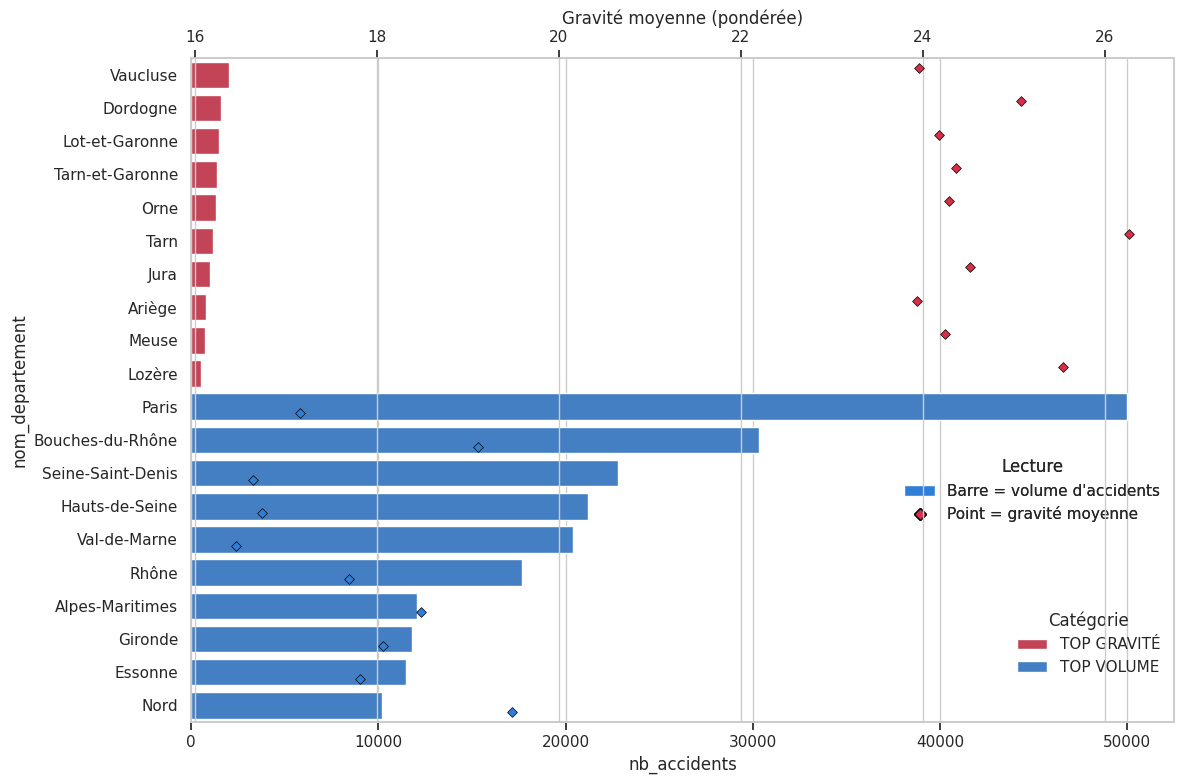

In [102]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

df = df_5_3

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 8))

palette = {"TOP VOLUME": "#2F7ED8", "TOP GRAVITÉ": "#D82F48"}
sns.barplot(
    data=df,
    y="nom_departement",
    x="nb_accidents",
    hue="categorie",
    palette=palette,
    orient="h",
    ax=ax1
)

cat_handles, cat_labels = ax1.get_legend_handles_labels()
cat_leg = ax1.legend(
    cat_handles,
    cat_labels,
    title="Catégorie",
    loc="lower right",
    bbox_to_anchor=(1, 0.05)  # ajuste un peu si besoin
)
ax1.add_artist(cat_leg)

symbol_handles = [
    Patch(facecolor="#2F7ED8", label="Barre = volume d'accidents"),
    Line2D([0], [0], color="#000000", marker="D", linestyle="None",
           markerfacecolor="#D82F48", markeredgecolor="black",
           label="Point = gravité moyenne")
]
symbol_leg = ax1.legend(
    handles=symbol_handles,
    title="Lecture",
    loc="lower right",
    bbox_to_anchor=(1, 0.28)  # pile juste au-dessus de l’autre
)
ax1.add_artist(symbol_leg)

ax2 = ax1.twiny()
sns.stripplot(
    data=df,
    y="nom_departement",
    x="gravite_moyenne",
    hue="categorie",
    palette=palette,
    ax=ax2,
    orient="h",
    dodge=True,
    marker="D",
    edgecolor="black",
    linewidth=0.5,
    legend=False
)
ax2.set_xlabel("Gravité moyenne (pondérée)")
plt.tight_layout()
plt.show()

In [103]:
section='6'
chapitre='1'
df_6_1 =execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_6_1.head()

WITH stats_hebdomadaires AS (
    SELECT
        an AS annee,
        EXTRACT(WEEK FROM make_date(an::int, mois::int, jour::int))::INT AS semaine,
        DATE_TRUNC('week', make_date(an::int, mois::int, jour::int))::DATE AS date_debut_semaine,
        COUNT(*) AS nb_accidents,
        SUM(nb_tues) AS nb_tues,
        SUM(nb_usagers_total) AS nb_personnes_impliquees,
        SUM(100 * nb_tues + 7 * nb_blesses)::NUMERIC AS somme_scores
    FROM analytics.accident_usagers_aggr
    WHERE an IS NOT NULL AND mois IS NOT NULL AND jour IS NOT NULL
    GROUP BY an, EXTRACT(WEEK FROM make_date(an::int, mois::int, jour::int)), DATE_TRUNC('week', make_date(an::int, mois::int, jour::int))
),
hebdo_calc AS (
    SELECT
        annee,
        semaine,
        date_debut_semaine,
        nb_accidents,
        nb_tues,
        CASE WHEN nb_personnes_impliquees = 0 THEN NULL
             ELSE somme_scores / nb_personnes_impliquees END AS gravite_moyenne
    FROM stats_hebdomadaires
),
stats_globales AS

,annee,semaine,date_debut_semaine,nb_accidents,moyenne_nationale,ecart_absolu,z_score_volume,z_score_gravite,nb_tues,gravite_moyenne,type_anomalie,tendance
0,2018,1,2018-12-31,94,1119.79,-1025.79,-4.95,-1.68,4,5.80,ANOMALIE EXTRÊME (>3σ),CREUX anormal
1,2017,52,2016-12-26,111,1119.79,-1008.79,-4.87,1.44,8,7.39,ANOMALIE EXTRÊME (>3σ),CREUX anormal
2,2012,1,2012-12-31,113,1119.79,-1006.79,-4.86,3.95,13,8.68,ANOMALIE EXTRÊME (>3σ),CREUX anormal
3,2012,52,2011-12-26,141,1119.79,-978.79,-4.72,9.23,21,11.37,ANOMALIE EXTRÊME (>3σ),CREUX anormal
4,2013,1,2013-12-30,228,1119.79,-891.79,-4.30,-0.20,15,6.56,ANOMALIE EXTRÊME (>3σ),CREUX anormal


In [105]:
df = df_6_1

numeric_cols = [
    "nb_accidents", "moyenne_nationale", "ecart_absolu",
    "z_score_volume", "z_score_gravite", "nb_tues", "gravite_moyenne"
]
df[numeric_cols] = df[numeric_cols].astype(float)

df["couleur"] = df["type_anomalie"].map({
    "ANOMALIE EXTRÊME (>3σ)": "#d73027",
    "ANOMALIE FORTE (>2σ)": "#fc8d59",
    "ANOMALIE MODÉRÉE (>1.5σ)": "#fee08b",
    "NORMAL": "#91bfdb",
})

fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True,
    row_heights=[0.65, 0.35], vertical_spacing=0.05,
    subplot_titles=("Accidents hebdomadaires vs moyenne nationale", "z-score du volume d'accidents")
)

fig.add_trace(go.Scatter(
    x=df["date_debut_semaine"], y=df["nb_accidents"],
    mode="markers+lines", marker=dict(color=df["couleur"], size=10, line=dict(width=1, color="#333")),
    name="Accidents hebdomadaires"
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df["date_debut_semaine"], y=df["moyenne_nationale"],
    mode="lines", line=dict(color="#636363", dash="dash"),
    name="Moyenne nationale"
), row=1, col=1)

fig.add_hrect(
    y0=df["moyenne_nationale"].iloc[0] - 2*df["ecart_absolu"].std(),
    y1=df["moyenne_nationale"].iloc[0] + 2*df["ecart_absolu"].std(),
    fillcolor="rgba(200,200,200,0.2)", line_width=0, row=1, col=1
)

fig.add_trace(go.Bar(
    x=df["date_debut_semaine"], y=df["z_score_volume"],
    marker_color=df["couleur"], name="z-score volume"
), row=2, col=1)

fig.update_layout(
    height=650, template="plotly_white",
    xaxis=dict(title="Semaine"),
    yaxis=dict(title="Nombre d'accidents"),
    yaxis2=dict(title="z-score volume"),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig.show()

In [107]:
section='6'
chapitre='2'
df_6_2 =execute_sql_to_df(db_conf, db_conf["db_accm"], SQL_FILES_PATH/sql_file_conf["sections"][f"section_{section}"]["file"],sql_file_conf["sections"][f"section_{section}"]["name"],sql_file_conf["sections"][f"section_{section}"]["chapitres"][f"chapitre_{chapitre}"])
df_6_2.head()

WITH stats AS (
    SELECT
        mois,
        CASE WHEN EXTRACT(ISODOW FROM make_date(an::int, mois::int, jour::int)) IN (6, 7) THEN TRUE ELSE FALSE END AS est_weekend,
        COUNT(*) AS nb_accidents,
        SUM(nb_tues) AS nb_tues,
        SUM(nb_usagers_total) AS nb_personnes_impliquees,
        SUM(100 * nb_tues + 10 * nb_blesses)::NUMERIC AS somme_scores
    FROM analytics.accident_usagers_aggr
    WHERE an IS NOT NULL AND mois IS NOT NULL AND jour IS NOT NULL
    GROUP BY mois, CASE WHEN EXTRACT(ISODOW FROM make_date(an::int, mois::int, jour::int)) IN (6, 7) THEN TRUE ELSE FALSE END
)
SELECT
    mois,
    CASE mois
        WHEN 1 THEN 'Janvier'
        WHEN 2 THEN 'Février'
        WHEN 3 THEN 'Mars'
        WHEN 4 THEN 'Avril'
        WHEN 5 THEN 'Mai'
        WHEN 6 THEN 'Juin'
        WHEN 7 THEN 'Juillet'
        WHEN 8 THEN 'Août'
        WHEN 9 THEN 'Septembre'
        WHEN 10 THEN 'Octobre'
        WHEN 11 THEN 'Novembre'
        WHEN 12 THEN 'Décembre'
    END AS nom

,mois,nom_mois,est_weekend,nb_accidents,gravite_moyenne,nb_tues
0,1,Janvier,False,28281,7.92,1455
1,1,Janvier,True,8358,9.18,657
2,2,Février,False,23945,8.11,1347
3,2,Février,True,7986,8.96,578
4,3,Mars,False,27214,7.78,1324


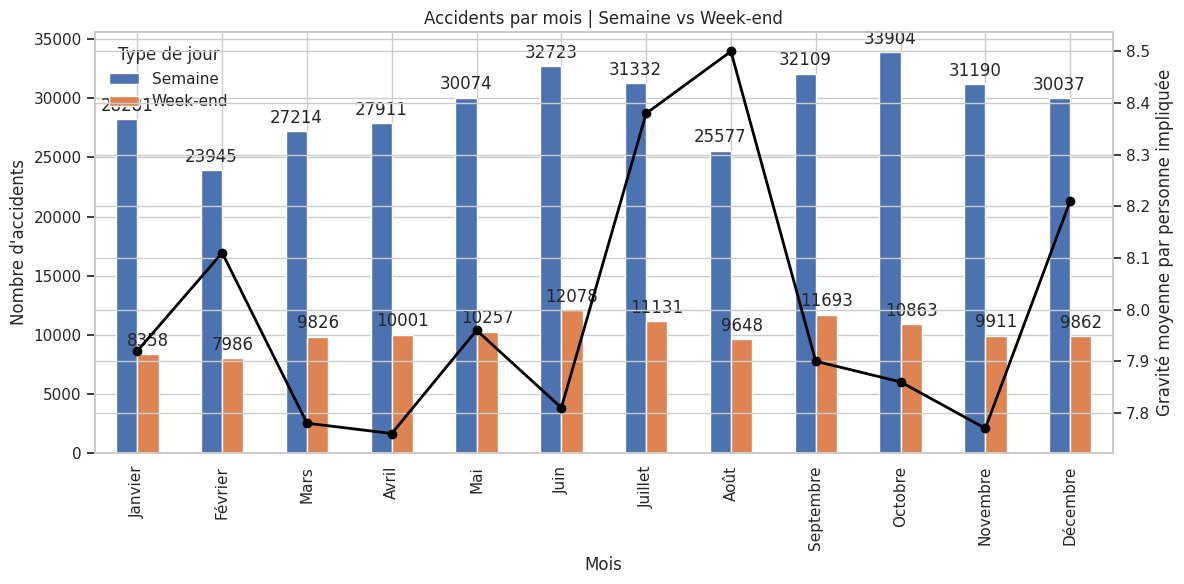

In [108]:
df_anomalies = df_6_2

df_anomalies["est_weekend_label"] = df_anomalies["est_weekend"].map({True: "Week-end", False: "Semaine"})
mois_order = df_anomalies.sort_values("mois")["nom_mois"].unique()
pivot_accidents = (
    df_anomalies.pivot(index="nom_mois", columns="est_weekend_label", values="nb_accidents")
    .reindex(mois_order)
    .fillna(0)
)

# 3. Construction du graphique
fig, ax1 = plt.subplots(figsize=(12, 6))

# Histogrammes groupés
pivot_accidents.plot(kind="bar", ax=ax1)
ax1.set_ylabel("Nombre d'accidents")
ax1.set_xlabel("Mois")
ax1.set_title("Accidents par mois | Semaine vs Week-end")
ax1.legend(title="Type de jour")

# Courbe de gravité moyenne sur axe secondaire
ax2 = ax1.twinx()
ax2.plot(
    df_anomalies.sort_values(["mois", "est_weekend"])["nom_mois"].unique(),
    df_anomalies.drop_duplicates("mois").sort_values("mois")["gravite_moyenne"],
    color="black",
    marker="o",
    linewidth=2,
    label="Gravité moyenne"
)
ax2.set_ylabel("Gravité moyenne par personne impliquée")

# Annotations nb_tues sur les barres
for container in ax1.containers:
    ax1.bar_label(container, labels=[f"{v:.0f}" for v in container.datavalues], padding=3)

plt.tight_layout()
plt.show()